# 🎯 Problem Statement

MicroEarnHUB: Students have skills but struggle to monetize them, while others need help but cannot find the right talent.

This project aims to:
- Analyze student skill supply and demand
- Identify gaps in the marketplace
- Predict adoption and earnings

### 🔍 Key Problem:
Mismatch between student skill supply and hiring demand.

In [40]:
!pip install openpyxl scikit-learn xgboost matplotlib seaborn plotly pandas numpy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('jupyter_client').setLevel(logging.ERROR)

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3','#8C8C8C']

print('✅ All libraries imported!')

✅ All libraries imported!


In [41]:
# Additional install for Association Rule Mining
!pip install mlxtend -q
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
print("✅ mlxtend loaded for Association Rule Mining")

✅ mlxtend loaded for Association Rule Mining


In [42]:
# Loading Data
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()  # A file picker dialog will appear

# Get the filename dynamically
filename = list(uploaded.keys())[0]
df_raw = pd.read_excel(io.BytesIO(uploaded[filename]))

print(f'✅ Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print(df_raw.head(3))

Saving MicroEarnHub_Combined_245_Responses.xlsx to MicroEarnHub_Combined_245_Responses (1).xlsx
✅ Dataset loaded: 245 rows × 24 columns
   S.No               Timestamp   Full Name                      Email ID  \
0     1 2026-02-12 00:52:46.021      dscdfv               aashi@gmail.com   
1     2 2026-02-12 00:53:16.634  Shubhangi   shubhangibhagat004@gmail.com   
2     3 2026-02-12 01:09:07.044       Ekta        singhekta2004@gmail.com   

   Current Academic Level               Which role best describes you?  \
0  3rd Year Undergraduate  I may need help/support from other students   
1  3rd Year Undergraduate     I want to offer my skills and earn money   
2  3rd Year Undergraduate     I want to offer my skills and earn money   

  Department / Stream                   Which skill areas can you offer?  \
0                  IT                                                NaN   
1         B.Tech CSE   Web / App Development & Technical Projects, Gr...   
2       Data science   Web / A

In [43]:
#Data Overview
import warnings
warnings.filterwarnings("ignore")
print('RAW DATA OVERVIEW')

print(f'Total Responses : {df_raw.shape[0]}')
print(f'Total Columns   : {df_raw.shape[1]}')
print(f'Date Range      : {df_raw["Timestamp"].min().date()} → {df_raw["Timestamp"].max().date()}')
print()

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('MISSING VALUES:')
print(missing_df)
print()
print('DATA SOURCE:')
print(df_raw['Source'].value_counts())

RAW DATA OVERVIEW
Total Responses : 245
Total Columns   : 24
Date Range      : 2026-02-12 → 2026-03-02

MISSING VALUES:
                                                    Missing Count  Missing %
Your last hiring experience (if any)                          201       82.0
Your last paid work (if any)                                  167       68.2
In which areas would you consider hiring anothe...            123       50.2
How often do you think you may need such support?             123       50.2
Have you actually hired/paid a student before?                123       50.2
Preferred Budget Range per Task                               123       50.2
What matters most when selecting a student for ...            123       50.2
Availability per Week                                          57       23.3
Have you earned money using your skills before?                57       23.3
Experience Level                                               57       23.3
Which skill areas can you offer? 

In [44]:
#Data Cleaning
df = df_raw.copy()

df.columns = [
    'sno','timestamp','name','email','academic_level','role',
    'department','skills_offered','experience_level','earned_before',
    'last_paid_work','expected_price_range','availability_week',
    'challenges','needs_to_hire','hire_areas','hired_before',
    'last_hiring_exp','hire_frequency','preferred_budget',
    'hiring_priorities','platform_adoption','trust_features','source'
]

exp_map = {
    'Beginner (no projects yet)':            'Beginner',
    'Intermediate (1–3 projects done)':      'Intermediate',
    'Intermediate (1–3 projects)':           'Intermediate',
    'Skilled (5+ projects done)':            'Skilled',
    'Experienced (regular work/freelancing)':'Experienced',
    'Experienced (1+ year experience)':      'Experienced',
}
df['experience_level'] = df['experience_level'].map(exp_map).fillna('Unknown')

avail_map = {
    'Less than 5 hours': '<5 hrs',
    '1–5 hours':         '<5 hrs',
    '5–10 hours':        '5–10 hrs',
    '6–10 hours':        '5–10 hrs',
    '10–15 hours':       '10–15 hrs',
    '15–20 hours':       '15–20 hrs',
    '15+ hours':         '15–20 hrs',
    '20+ hours':         '20+ hrs',
}
df['availability_week'] = df['availability_week'].map(avail_map).fillna('Unknown')

for col in ['hire_areas','hired_before','hire_frequency','preferred_budget','hiring_priorities',
            'skills_offered','experience_level','earned_before','expected_price_range',
            'availability_week','challenges']:
    df[col] = df[col].fillna('N/A')

df['month']       = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.day_name()
df['hour']        = df['timestamp'].dt.hour

print('✅ Cleaning done! Shape:', df.shape)
print(df.head(3))

✅ Cleaning done! Shape: (245, 27)
   sno               timestamp        name                         email  \
0    1 2026-02-12 00:52:46.021      dscdfv               aashi@gmail.com   
1    2 2026-02-12 00:53:16.634  Shubhangi   shubhangibhagat004@gmail.com   
2    3 2026-02-12 01:09:07.044       Ekta        singhekta2004@gmail.com   

           academic_level                                         role  \
0  3rd Year Undergraduate  I may need help/support from other students   
1  3rd Year Undergraduate     I want to offer my skills and earn money   
2  3rd Year Undergraduate     I want to offer my skills and earn money   

      department                                     skills_offered  \
0             IT                                                N/A   
1    B.Tech CSE   Web / App Development & Technical Projects, Gr...   
2  Data science   Web / App Development & Technical Projects, Co...   

  experience_level            earned_before  ...      last_hiring_exp  \
0     

In [45]:
import numpy as np
import pandas as pd

# Feature Engineering

# Price range → numeric midpoint
price_mid = {
    'Under ₹500': 250,
    '₹500 – ₹1,500': 1000,
    '₹1,500 – ₹3,000': 2250,
    '₹3,000+': 4000,
    'N/A': np.nan
}
df['expected_price_mid']   = df['expected_price_range'].map(price_mid)
df['preferred_budget_mid'] = df['preferred_budget'].map(price_mid)

# Availability → numeric hours
avail_mid = {
    '<5 hrs': 3,
    '5–10 hrs': 7,
    '10–15 hrs': 12,
    '15–20 hrs': 17,
    '20+ hrs': 22,
    'Unknown': np.nan
}
df['availability_hours'] = df['availability_week'].map(avail_mid)

# Role flags
df['is_freelancer'] = df['role'].str.contains('offer', case=False, na=False).astype(int)
df['is_hirer']      = df['role'].str.contains('hire|help|support', case=False, na=False).astype(int)

# Experience score
exp_score = {'Beginner': 1, 'Intermediate': 2, 'Skilled': 3, 'Experienced': 4, 'Unknown': 0}
df['experience_score'] = df['experience_level'].map(exp_score)

# Adoption score & binary target
adopt_map = {'Yes, definitely': 3, 'Probably yes': 2, 'Maybe': 1, 'Probably no': 0}
df['adoption_score'] = df['platform_adoption'].map(adopt_map)
df['will_adopt']     = (df['adoption_score'] >= 2).astype(int)

# Has earned
df['has_earned'] = df['earned_before'].apply(lambda x: 1 if x == 'Yes' else 0)

# Primary skill category
def get_primary_skill(s):
    if pd.isna(s) or s == 'N/A': return 'Unknown'
    s = s.lower()
    if 'web' in s or 'app' in s:                        return 'Web/App Dev'
    if 'data' in s or 'excel' in s or 'analysis' in s: return 'Data & Analytics'
    if 'graphic' in s or 'ui' in s or 'canva' in s:    return 'Design'
    if 'content' in s or 'writing' in s:                return 'Content & Marketing'
    if 'video' in s or 'media' in s:                    return 'Video & Media'
    if 'social' in s:                                   return 'Social Media'
    if 'coding' in s or 'debug' in s:                   return 'Coding'
    if 'research' in s or 'project' in s:               return 'Research Support'
    return 'Other'

df['primary_skill'] = df['skills_offered'].apply(get_primary_skill)

# Department group
def group_dept(d):
    if pd.isna(d): return 'Unknown'
    d = d.lower()
    if any(x in d for x in ['cse', 'it', 'computer', 'data science']): return 'CS/IT'
    if any(x in d for x in ['civil', 'mechanical', 'electrical']):      return 'Engineering'
    if any(x in d for x in ['media', 'mass comm', 'communication']):    return 'Media/Comm'
    if any(x in d for x in ['finance', 'commerce', 'bba', 'mba']):      return 'Business'
    if any(x in d for x in ['psychology', 'arts', 'humanities']):       return 'Arts/Social'
    if any(x in d for x in ['architecture', 'design']):                 return 'Design/Arch'
    return 'Other'

df['dept_group'] = df['department'].apply(group_dept)

# Monthly earning potential
df['monthly_earning_potential'] = np.where(
    df['is_freelancer'] == 1,
    df['expected_price_mid'] * df['availability_hours'] * 0.5,
    np.nan
)

print('✅ Feature engineering done!')
print(df[['expected_price_mid', 'availability_hours', 'experience_score',
          'adoption_score', 'monthly_earning_potential', 'primary_skill', 'dept_group']].head(6))

✅ Feature engineering done!
   expected_price_mid  availability_hours  experience_score  adoption_score  \
0                 NaN                 NaN                 0               2   
1              1000.0                12.0                 1               2   
2              2250.0                 7.0                 2               3   
3              1000.0                 7.0                 2               2   
4              4000.0                 3.0                 4               3   
5              1000.0                 7.0                 1               1   

   monthly_earning_potential        primary_skill dept_group  
0                        NaN              Unknown      CS/IT  
1                     6000.0          Web/App Dev      CS/IT  
2                     7875.0          Web/App Dev      CS/IT  
3                     3500.0          Web/App Dev      CS/IT  
4                     6000.0          Web/App Dev      CS/IT  
5                     3500.0  Content & 

In [46]:
# Dimension Tables
dim_student = df[['sno','name','academic_level','dept_group','experience_level',
                   'experience_score','role','is_freelancer','is_hirer']].rename(columns={'sno':'student_id'})

dim_skill = df[['sno','primary_skill','skills_offered']].rename(columns={'sno':'student_id'})

dim_time = df[['sno','timestamp','month','day_of_week','hour']].rename(columns={'sno':'student_id'})

dim_platform = df[['sno','platform_adoption','adoption_score','will_adopt',
                    'trust_features','challenges']].rename(columns={'sno':'student_id'})

# Fact Table
fact_survey = df[['sno','expected_price_mid','preferred_budget_mid','availability_hours',
                   'monthly_earning_potential','has_earned','adoption_score','will_adopt',
                   'experience_score','is_freelancer','is_hirer','needs_to_hire',
                   'hired_before','hire_frequency','source']].rename(columns={'sno':'student_id'})

print(' STAR SCHEMA — DATA WAREHOUSE')
print('-'*50)
print(f'  FACT TABLE  : fact_survey  → {fact_survey.shape}')
print(f'  DIM TABLE   : dim_student  → {dim_student.shape}')
print(f'  DIM TABLE   : dim_skill    → {dim_skill.shape}')
print(f'  DIM TABLE   : dim_time     → {dim_time.shape}')
print(f'  DIM TABLE   : dim_platform → {dim_platform.shape}')
print()
print('Fact Table Sample:')
print(fact_survey.head(5))

 STAR SCHEMA — DATA WAREHOUSE
--------------------------------------------------
  FACT TABLE  : fact_survey  → (245, 15)
  DIM TABLE   : dim_student  → (245, 9)
  DIM TABLE   : dim_skill    → (245, 3)
  DIM TABLE   : dim_time     → (245, 5)
  DIM TABLE   : dim_platform → (245, 6)

Fact Table Sample:
   student_id  expected_price_mid  preferred_budget_mid  availability_hours  \
0           1                 NaN                 250.0                 NaN   
1           2              1000.0                   NaN                12.0   
2           3              2250.0                   NaN                 7.0   
3           4              1000.0                   NaN                 7.0   
4           5              4000.0                   NaN                 3.0   

   monthly_earning_potential  has_earned  adoption_score  will_adopt  \
0                        NaN           0               2           1   
1                     6000.0           0               2           1   
2      

 DATA CUBE: Academic Level × Experience → Avg Expected Price (₹)
experience_level        Beginner  Experienced  Intermediate  Skilled     ALL
academic_level                                                              
1st Year Undergraduate    2531.0       2200.0        2071.0      NaN  2333.0
2nd Year Undergraduate    2100.0       1485.0        2219.0      NaN  1783.0
3rd Year Undergraduate    1278.0       2111.0        2140.0   3708.0  2164.0
4th Year Undergraduate    2562.0       1979.0        1625.0      NaN  2077.0
Postgraduate              2346.0       1950.0        1125.0      NaN  2034.0
Alumni                    1571.0       1929.0        2450.0      NaN  1934.0
ALL                       2147.0       1888.0        2055.0   3708.0  2082.0

 SLICE: academic_level = "3rd Year Undergraduate"
                     Count  Avg_Price  Monthly_Potential
primary_skill                                           
Web/App Dev             29     2500.0             7461.2
Data & Analytics    

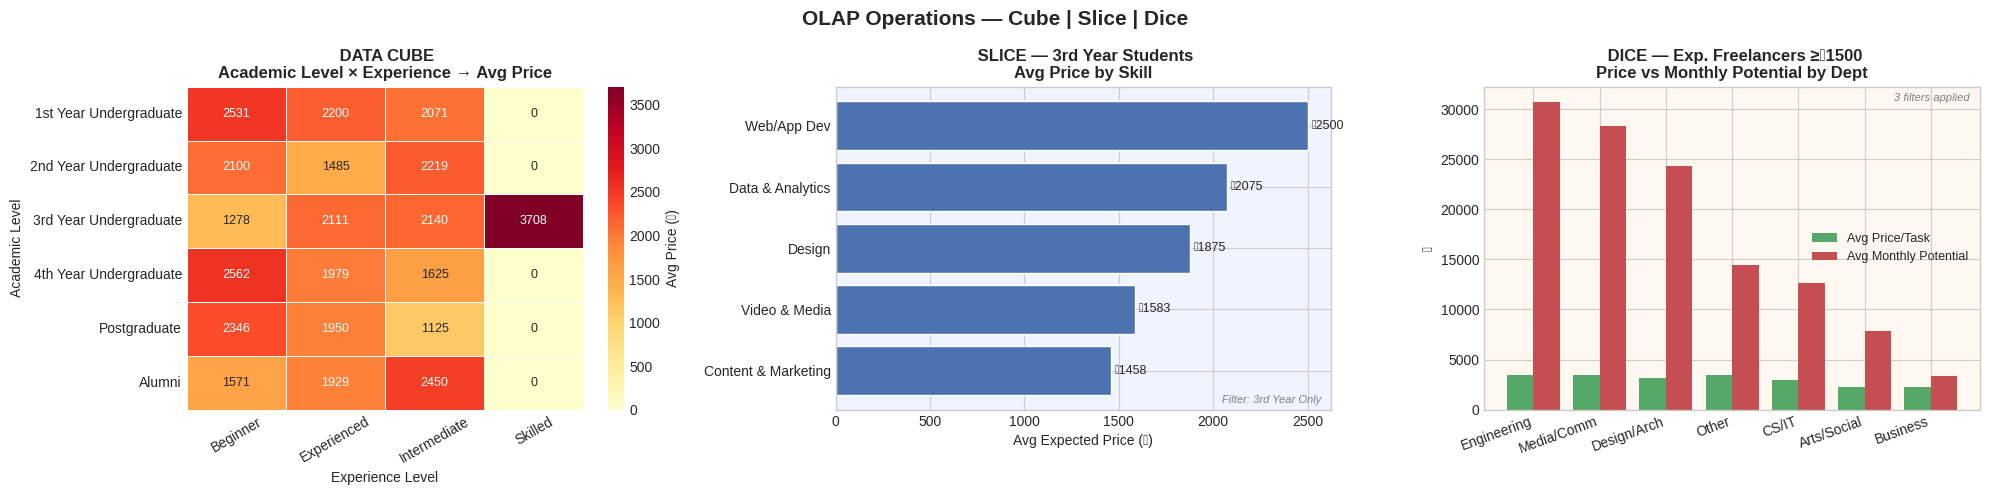

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
olap_df = fact_survey.merge(dim_student[['student_id','academic_level','dept_group','experience_level']], on='student_id')
olap_df = olap_df.merge(dim_skill[['student_id','primary_skill']], on='student_id')

# DATA CUBE
print(' DATA CUBE: Academic Level × Experience → Avg Expected Price (₹)')
cube = olap_df.pivot_table(
    values='expected_price_mid', index='academic_level', columns='experience_level',
    aggfunc='mean', margins=True, margins_name='ALL'
).round(0)
level_order = ['1st Year Undergraduate','2nd Year Undergraduate','3rd Year Undergraduate',
               '4th Year Undergraduate','Postgraduate','Alumni','ALL']
cube = cube.reindex([l for l in level_order if l in cube.index])
print(cube.to_string())

# Cube as heatmap
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('OLAP Operations — Cube | Slice | Dice', fontsize=15, fontweight='bold')

cube_plot = cube.drop('ALL', errors='ignore').drop('ALL', axis=1, errors='ignore').fillna(0)
sns.heatmap(cube_plot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, annot_kws={'size':9}, cbar_kws={'label':'Avg Price (₹)'})
axes[0].set_title(' DATA CUBE\nAcademic Level × Experience → Avg Price', fontweight='bold')
axes[0].set_xlabel('Experience Level')
axes[0].set_ylabel('Academic Level')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# SLICE
print('\n SLICE: academic_level = "3rd Year Undergraduate"')
slice_3rd = olap_df[olap_df['academic_level'] == '3rd Year Undergraduate']
slice_summary = slice_3rd.groupby('primary_skill').agg(
    Count=('student_id','count'),
    Avg_Price=('expected_price_mid','mean'),
    Monthly_Potential=('monthly_earning_potential','mean')
).round(1).sort_values('Avg_Price', ascending=False)
print(slice_summary.to_string())

# Slice as horizontal bar
slice_plot = slice_summary.dropna(subset=['Avg_Price']).sort_values('Avg_Price')
bars = axes[1].barh(slice_plot.index, slice_plot['Avg_Price'], color='#4C72B0', edgecolor='white')
axes[1].set_title(' SLICE — 3rd Year Students\nAvg Price by Skill', fontweight='bold')
axes[1].set_xlabel('Avg Expected Price (₹)')
for bar, val in zip(bars, slice_plot['Avg_Price']):
    axes[1].text(val + 20, bar.get_y() + bar.get_height()/2, f'₹{val:.0f}', va='center', fontsize=9)
axes[1].set_facecolor('#f0f4ff')
axes[1].text(0.98, 0.02, 'Filter: 3rd Year Only', transform=axes[1].transAxes,
             ha='right', fontsize=8, color='gray', style='italic')

# DICE
print('\n DICE: Experienced/Skilled + Freelancer + Price ≥ ₹1500')
dice = olap_df[
    (olap_df['experience_level'].isin(['Experienced','Skilled'])) &
    (olap_df['is_freelancer'] == 1) &
    (olap_df['expected_price_mid'] >= 1500)
]
dice_summary = dice.groupby('dept_group').agg(
    Count=('student_id','count'),
    Avg_Price=('expected_price_mid','mean'),
    Avg_Monthly=('monthly_earning_potential','mean')
).round(1).sort_values('Avg_Monthly', ascending=False)
print(dice_summary.to_string())

# Dice as grouped bar
x = np.arange(len(dice_summary))
w = 0.4
axes[2].bar(x - w/2, dice_summary['Avg_Price'], w, label='Avg Price/Task', color='#55A868')
axes[2].bar(x + w/2, dice_summary['Avg_Monthly'], w, label='Avg Monthly Potential', color='#C44E52')
axes[2].set_xticks(x)
axes[2].set_xticklabels(dice_summary.index, rotation=20, ha='right')
axes[2].set_title(' DICE — Exp. Freelancers ≥₹1500\nPrice vs Monthly Potential by Dept', fontweight='bold')
axes[2].set_ylabel('₹')
axes[2].legend(fontsize=9)
axes[2].set_facecolor('#fff8f0')
axes[2].text(0.98, 0.98, '3 filters applied', transform=axes[2].transAxes,
             ha='right', va='top', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('olap_cube_slice_dice.png', dpi=150, bbox_inches='tight')
plt.show()

 ROLL-UP: Department → Dept Group → Grand Total

LEVEL 1 (Dept):
department
Btech data science                     4000.0
Btech                                  4000.0
Btech cse core                         4000.0
CSE Iot                                4000.0
Department of Computer Applications    4000.0
Cse aiml                               4000.0
Information technology                 4000.0
MBA                                    4000.0

LEVEL 2 (Group):
dept_group
Design/Arch    2643.0
Media/Comm     2371.0
CS/IT          2182.0
Engineering    2162.0
Other          2000.0
Arts/Social    1617.0
Business       1547.0

LEVEL 3 (ALL): ₹2082

 DRILL-DOWN: CS/IT Group → Departments → Skills

LEVEL 1 (CS/IT group): ₹10048/month avg

LEVEL 2 (by dept):
department
Data Science                           14104.0
Btech cse core                         14000.0
Department of Computer Applications    14000.0
Architecture                           13536.0
Cse iot                                135

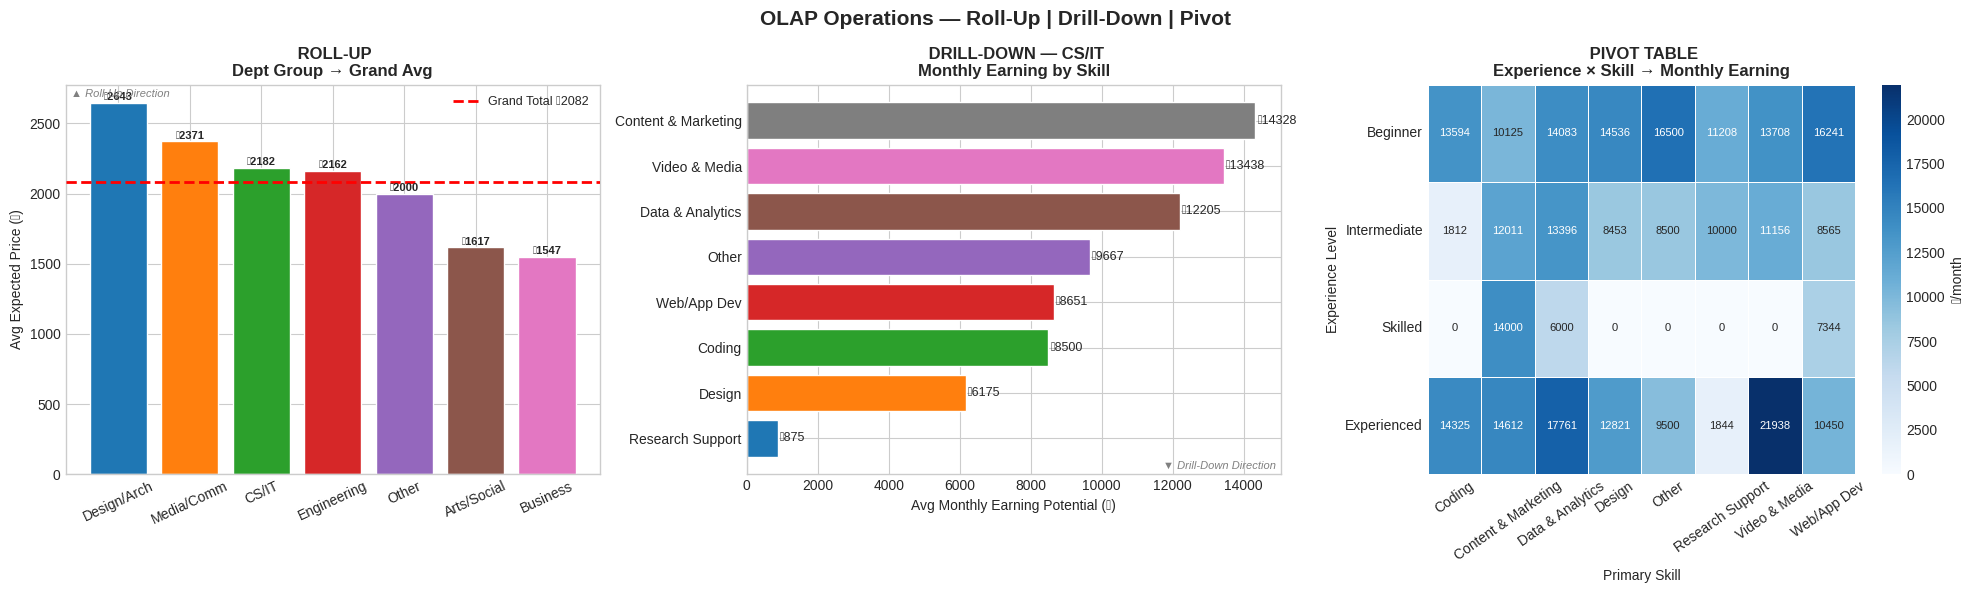

In [48]:
import matplotlib.cm as cm
COLORS = cm.tab10.colors  # built-in 10-color palette
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('OLAP Operations — Roll-Up | Drill-Down | Pivot', fontsize=15, fontweight='bold')

# ROLL-UP
print(' ROLL-UP: Department → Dept Group → Grand Total')

level1 = df.groupby('department')['expected_price_mid'].mean().dropna().sort_values(ascending=False).head(8)
level2 = df.groupby('dept_group')['expected_price_mid'].mean().dropna().sort_values(ascending=False)
level3_val = df['expected_price_mid'].mean()

print('\nLEVEL 1 (Dept):'); print(level1.round(0).to_string())
print('\nLEVEL 2 (Group):'); print(level2.round(0).to_string())
print(f'\nLEVEL 3 (ALL): ₹{level3_val:.0f}')

# Roll-up as layered bars — level2 + grand total line
colors_rollup = [COLORS[i % len(COLORS)] for i in range(len(level2))]
bars = axes[0].bar(level2.index, level2.values, color=colors_rollup, edgecolor='white', zorder=2)
axes[0].axhline(level3_val, color='red', linestyle='--', linewidth=2, label=f'Grand Total ₹{level3_val:.0f}', zorder=3)
axes[0].set_title(' ROLL-UP\nDept Group → Grand Avg', fontweight='bold')
axes[0].set_ylabel('Avg Expected Price (₹)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(fontsize=9)
for bar, val in zip(bars, level2.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 20, f'₹{val:.0f}',
                 ha='center', fontsize=8, fontweight='bold')
axes[0].text(0.01, 0.99, '▲ Roll-Up Direction', transform=axes[0].transAxes,
             va='top', fontsize=8, color='gray', style='italic')

# DRILL-DOWN
print('\n DRILL-DOWN: CS/IT Group → Departments → Skills')
csit = df[df['dept_group'] == 'CS/IT']
drill2 = csit.groupby('department')['monthly_earning_potential'].mean().dropna().sort_values(ascending=False)
drill3 = csit.groupby('primary_skill')['monthly_earning_potential'].mean().dropna().sort_values(ascending=True)

print(f'\nLEVEL 1 (CS/IT group): ₹{csit["monthly_earning_potential"].mean():.0f}/month avg')
print('\nLEVEL 2 (by dept):'); print(drill2.round(0).to_string())
print('\nLEVEL 3 (by skill):'); print(drill3.round(0).to_string())

# Drill-down as horizontal bars for skills
colors_drill = [COLORS[i % len(COLORS)] for i in range(len(drill3))]
axes[1].barh(drill3.index, drill3.values, color=colors_drill, edgecolor='white')
axes[1].set_title(' DRILL-DOWN — CS/IT\nMonthly Earning by Skill', fontweight='bold')
axes[1].set_xlabel('Avg Monthly Earning Potential (₹)')
for i, val in enumerate(drill3.values):
    axes[1].text(val + 50, i, f'₹{val:.0f}', va='center', fontsize=9)
axes[1].text(0.99, 0.01, '▼ Drill-Down Direction', transform=axes[1].transAxes,
             ha='right', va='bottom', fontsize=8, color='gray', style='italic')

# PIVOT TABLE
print('\n PIVOT: Experience × Skill → Avg Monthly Earning (₹)')
pivot = olap_df.pivot_table(
    values='monthly_earning_potential', index='experience_level', columns='primary_skill',
    aggfunc='mean', margins=True, margins_name='AVG'
).round(0)
exp_order = ['Beginner','Intermediate','Skilled','Experienced','AVG']
pivot = pivot.reindex([e for e in exp_order if e in pivot.index])
print(pivot.to_string())

# Pivot as heatmap
pivot_plot = pivot.drop('AVG', errors='ignore').drop('AVG', axis=1, errors='ignore').fillna(0)
sns.heatmap(pivot_plot, annot=True, fmt='.0f', cmap='Blues', ax=axes[2],
            linewidths=0.5, annot_kws={'size':8}, cbar_kws={'label':'₹/month'})
axes[2].set_title(' PIVOT TABLE\nExperience × Skill → Monthly Earning', fontweight='bold')
axes[2].set_xlabel('Primary Skill')
axes[2].set_ylabel('Experience Level')
axes[2].tick_params(axis='x', rotation=35)
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('olap_rollup_drilldown_pivot.png', dpi=150, bbox_inches='tight')
plt.show()

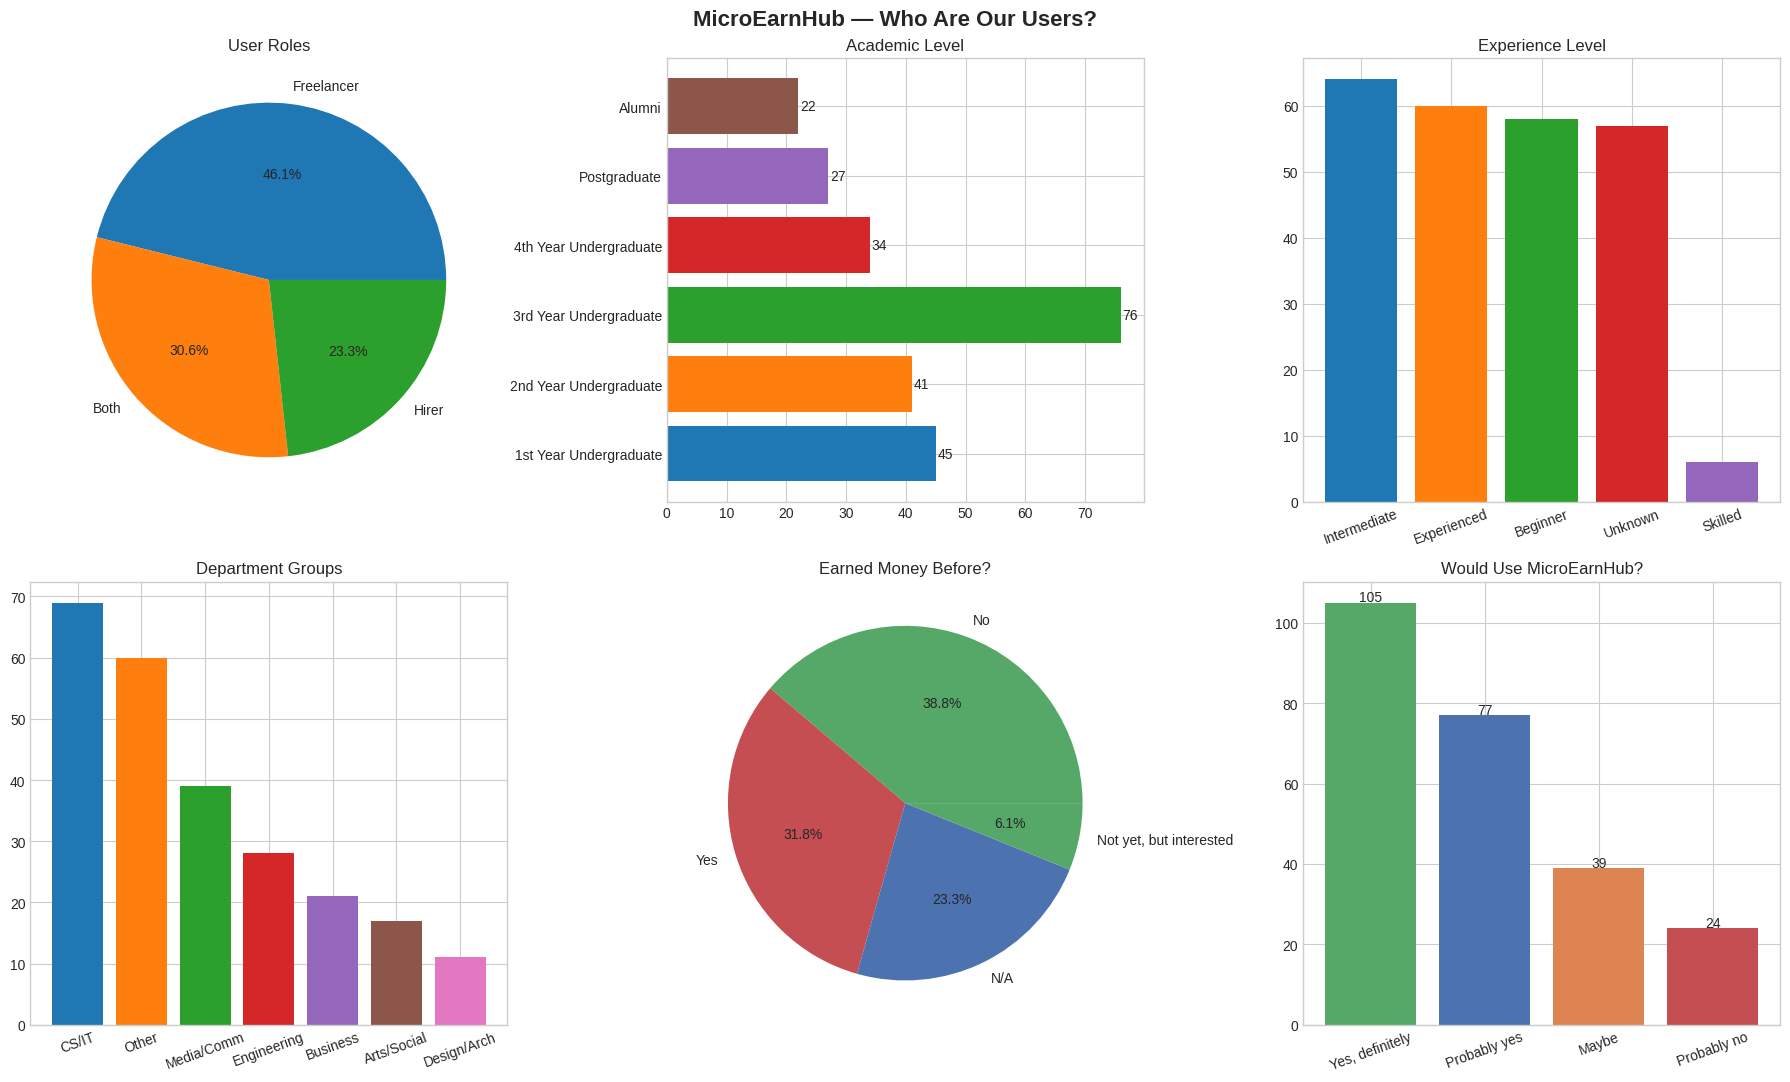

In [49]:
# User EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('MicroEarnHub — Who Are Our Users?', fontsize=16, fontweight='bold')

# Role distribution
role_counts = df['role'].value_counts()
axes[0,0].pie(role_counts.values, labels=['Freelancer','Both','Hirer'], autopct='%1.1f%%', colors=COLORS[:3])
axes[0,0].set_title('User Roles')

# Academic level
acad_order = ['1st Year Undergraduate','2nd Year Undergraduate','3rd Year Undergraduate',
              '4th Year Undergraduate','Postgraduate','Alumni']
acad = df['academic_level'].value_counts().reindex([a for a in acad_order if a in df['academic_level'].values])
axes[0,1].barh(acad.index, acad.values, color=COLORS)
axes[0,1].set_title('Academic Level')
for bar, v in zip(axes[0,1].patches, acad.values):
    axes[0,1].text(v+0.3, bar.get_y()+bar.get_height()/2, str(v), va='center')

# Experience level
exp_c = df['experience_level'].value_counts()
axes[0,2].bar(exp_c.index, exp_c.values, color=COLORS)
axes[0,2].set_title('Experience Level')
axes[0,2].tick_params(axis='x', rotation=20)

# Department group
dept_c = df['dept_group'].value_counts()
axes[1,0].bar(dept_c.index, dept_c.values, color=COLORS)
axes[1,0].set_title('Department Groups')
axes[1,0].tick_params(axis='x', rotation=20)

# Has earned
earned_c = df['earned_before'].value_counts()
axes[1,1].pie(earned_c.values, labels=earned_c.index, autopct='%1.1f%%', colors=['#55A868','#C44E52','#4C72B0'])
axes[1,1].set_title('Earned Money Before?')

# Platform adoption
adopt_order = ['Yes, definitely','Probably yes','Maybe','Probably no']
adopt_c = df['platform_adoption'].value_counts().reindex(adopt_order)
axes[1,2].bar(adopt_order, adopt_c.values, color=['#55A868','#4C72B0','#DD8452','#C44E52'])
axes[1,2].set_title('Would Use MicroEarnHub?')
axes[1,2].tick_params(axis='x', rotation=20)
for i, v in enumerate(adopt_c.values):
    axes[1,2].text(i, v+0.3, str(v), ha='center')

plt.tight_layout()
plt.savefig('eda_user_profile.png', dpi=150, bbox_inches='tight')
plt.show()

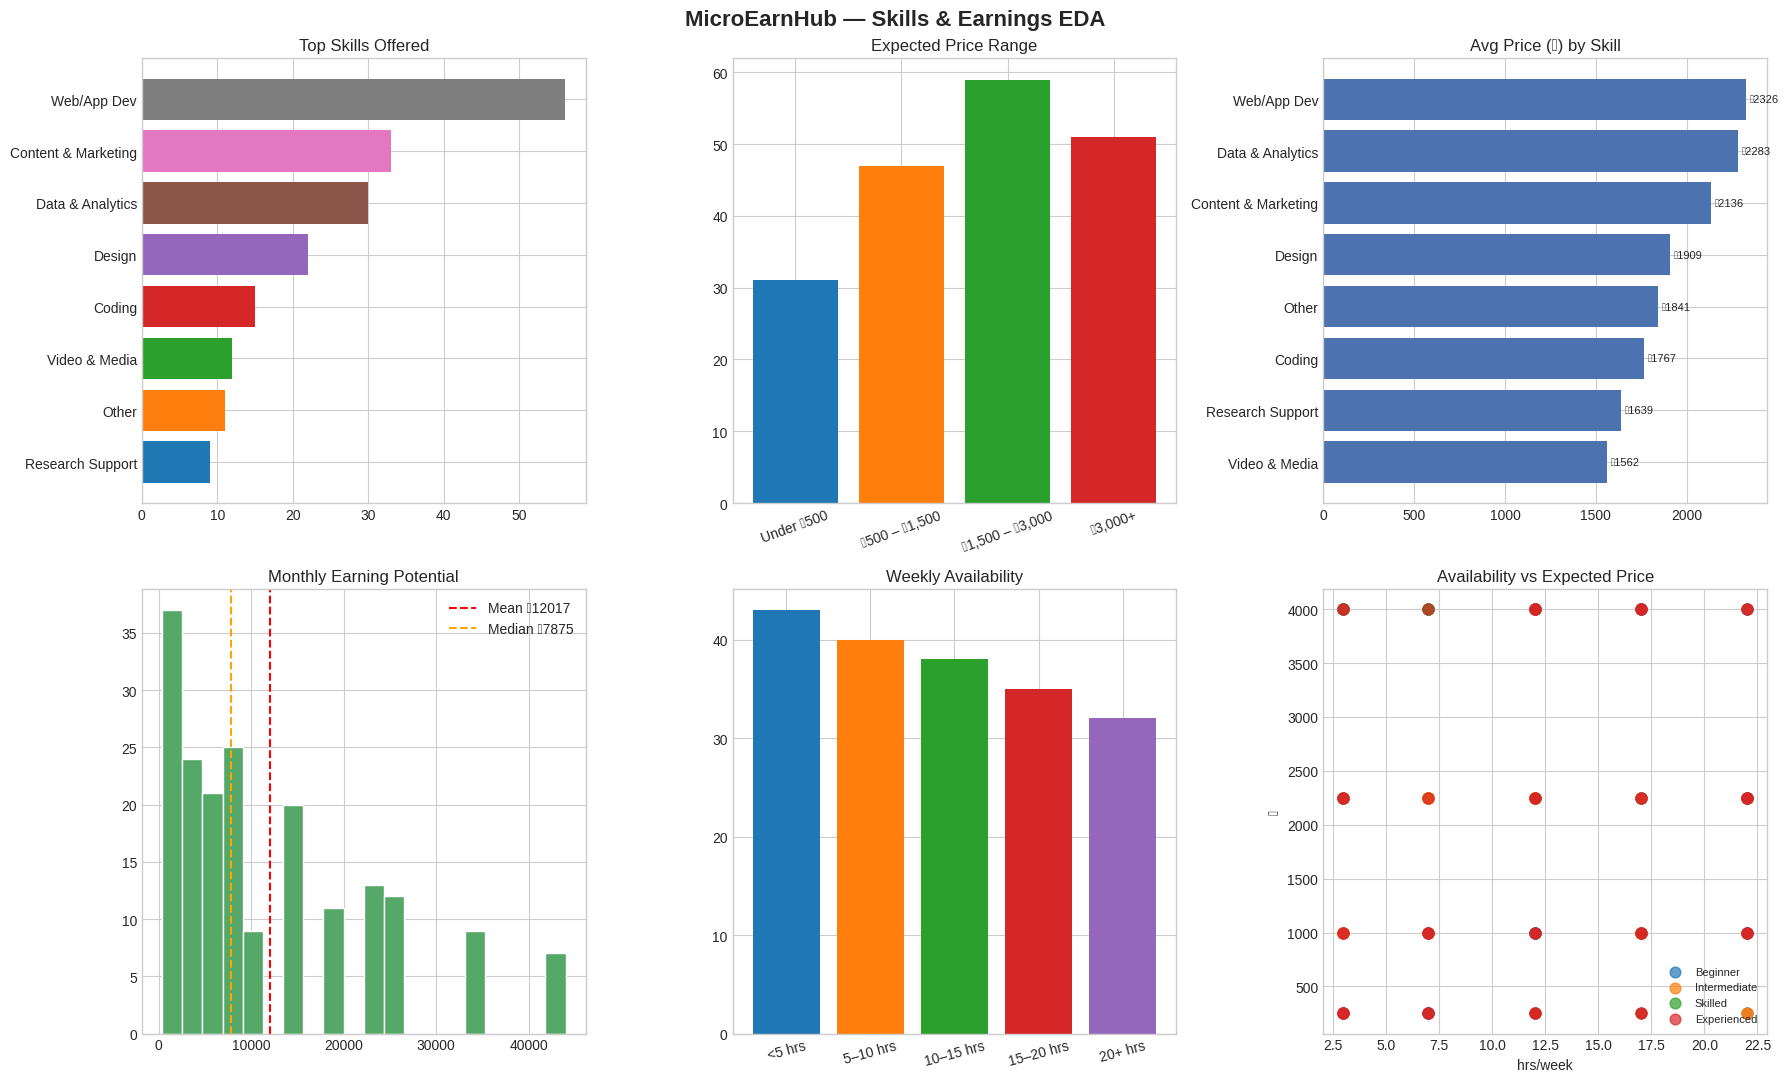

In [50]:
# Skills & Earnings EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('MicroEarnHub — Skills & Earnings EDA', fontsize=16, fontweight='bold')

df_clean = df[df['primary_skill'].notna()]
df_clean = df_clean[df_clean['primary_skill'].str.strip().str.lower() != 'unknown']

# Top skills
sk = df_clean['primary_skill'].value_counts().head(8)
axes[0,0].barh(sk.index[::-1], sk.values[::-1], color=COLORS)
axes[0,0].set_title('Top Skills Offered')

# Price range
price_order = ['Under ₹500','₹500 – ₹1,500','₹1,500 – ₹3,000','₹3,000+']
price_c = df['expected_price_range'].value_counts().reindex(
    [p for p in price_order if p in df['expected_price_range'].values]
)
axes[0,1].bar(price_c.index, price_c.values, color=COLORS[:4])
axes[0,1].set_title('Expected Price Range')
axes[0,1].tick_params(axis='x', rotation=20)

# Avg price by skill
sp = df_clean.groupby('primary_skill')['expected_price_mid'].mean().dropna().sort_values()
axes[0,2].barh(sp.index, sp.values, color='#4C72B0')
axes[0,2].set_title('Avg Price (₹) by Skill')

for i, v in enumerate(sp.values):
    axes[0,2].text(v+20, i, f'₹{v:.0f}', va='center', fontsize=8)

# Monthly earning histogram
earn = df['monthly_earning_potential'].dropna()
axes[1,0].hist(earn, bins=20, color='#55A868', edgecolor='white')

axes[1,0].axvline(earn.mean(), color='red', linestyle='--',
                 label=f'Mean ₹{earn.mean():.0f}')
axes[1,0].axvline(earn.median(), color='orange', linestyle='--',
                 label=f'Median ₹{earn.median():.0f}')

axes[1,0].set_title('Monthly Earning Potential')
axes[1,0].legend()

# Availability
avail_order = ['<5 hrs','5–10 hrs','10–15 hrs','15–20 hrs','20+ hrs']
avail_c = df['availability_week'].value_counts().reindex(
    [a for a in avail_order if a in df['availability_week'].values]
)

axes[1,1].bar(avail_c.index, avail_c.values, color=COLORS[:5])
axes[1,1].set_title('Weekly Availability')
axes[1,1].tick_params(axis='x', rotation=15)

#  Price vs availability scatter
sc = df.dropna(subset=['expected_price_mid','availability_hours'])

for exp, color in zip(['Beginner','Intermediate','Skilled','Experienced'], COLORS):
    sub = sc[sc['experience_level'] == exp]
    axes[1,2].scatter(sub['availability_hours'],
                      sub['expected_price_mid'],
                      label=exp,
                      alpha=0.7,
                      color=color,
                      s=60)

axes[1,2].set_title('Availability vs Expected Price')
axes[1,2].set_xlabel('hrs/week')
axes[1,2].set_ylabel('₹')
axes[1,2].legend(fontsize=8)

# FINAL
plt.tight_layout()
plt.savefig('eda_skills_earnings.png', dpi=150, bbox_inches='tight')
plt.show()

    ASSOCIATION RULE MINING (APRIORI)
  Finding: What skills go together? Who offers & also hires?

✅ Frequent itemsets found : 49
✅ Association rules found : 31

 TOP 10 RULES BY LIFT (most interesting patterns):

Antecedent                     Consequent                      Support   Conf   Lift
-------------------------------------------------------------------------------------
HIRE:Excel                     HIRE:Data Analysis                9.80% 100.00%  10.21
HIRE:Data Analysis             HIRE:Excel                        9.80% 100.00%  10.21
HIRE:Tutoring                  HIRE:Academic Support            11.43% 100.00%   8.75
HIRE:Academic Support          HIRE:Tutoring                    11.43% 100.00%   8.75
HIRE:N/A, OFFER:Tutoring       OFFER:Academic Support            9.80% 100.00%   7.00
OFFER:Tutoring                 OFFER:Academic Support           14.29% 100.00%   7.00
OFFER:Academic Support         OFFER:Tutoring                   14.29% 100.00%   7.00
HIRE:N/A, OF

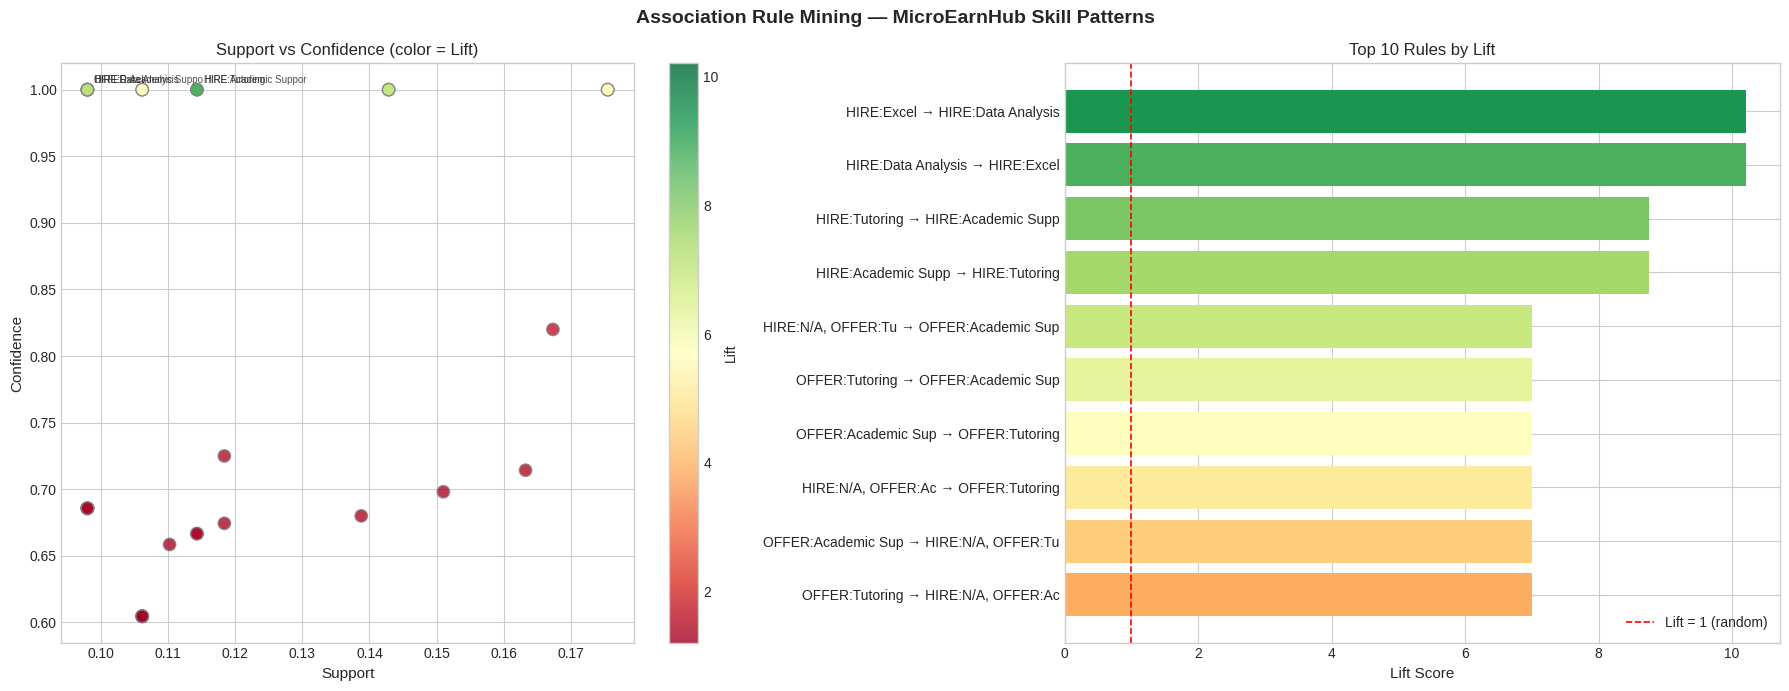


 Interpretation:
   Lift > 1  → skills appear together MORE than by chance
   Lift = 1  → no association
   Lift > 2  → very strong co-occurrence pattern


In [51]:
# Association Rule Mining
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings("ignore")

print("    ASSOCIATION RULE MINING (APRIORI)")
print("  Finding: What skills go together? Who offers & also hires?")


# Build Transactions
# Normalize slash variants
def clean_skill(s):
    return (s.strip()
             .replace(' / ', '/')
             .replace('Web / App Development & Technical Projects', 'Web/App Dev')
             .replace('Web/App Development & Technical Projects', 'Web/App Dev')
             .replace('Graphic / Canva & UI Design', 'Graphic/UI Design')
             .replace('Graphic/Canva & UI Design', 'Graphic/UI Design')
             .replace('Project / Research Support', 'Project/Research')
             .replace('Project/Research Support', 'Project/Research')
             .replace('PPT / Presentation Design', 'PPT Design')
             .replace('PPT/Presentation Design', 'PPT Design')
             .replace('Resume / LinkedIn / Career Help', 'Resume/Career Help')
             .replace('Resume/LinkedIn/Career Help', 'Resume/Career Help')
             .replace('Content Writing / Marketing & Promotion', 'Content Writing')
             .replace('Content Writing/Marketing & Promotion', 'Content Writing')
             .replace('Coding & Debugging Help', 'Coding/Debug')
             .replace('Video Editing & Media Work', 'Video Editing')
             .replace('Social Media Content & Management', 'Social Media')
             .replace('Assignments & Academic Support', 'Academic Support')
             .replace('Event or Club Support', 'Event Support')
             .replace('Data & Analysis Work', 'Data Analysis')
             )

transactions = []
for _, row in df.iterrows():
    basket = set()
    # Skills offered → prefix "OFFER:"
    if pd.notna(row['skills_offered']):
        for sk in row['skills_offered'].split(','):
            basket.add('OFFER:' + clean_skill(sk))
    # Skills wanted to hire → prefix "HIRE:"
    if pd.notna(row['hire_areas']):
        for sk in row['hire_areas'].split(','):
            basket.add('HIRE:' + clean_skill(sk))
    if basket:
        transactions.append(list(basket))

# Encode & Run Apriori
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

freq_items = apriori(basket_df, min_support=0.08, use_colnames=True)
rules = association_rules(freq_items, metric="confidence", min_threshold=0.4)
rules = rules.sort_values('lift', ascending=False)

print(f"\n✅ Frequent itemsets found : {len(freq_items)}")
print(f"✅ Association rules found : {len(rules)}")

# Top Rules
print("\n TOP 10 RULES BY LIFT (most interesting patterns):\n")
print(f"{'Antecedent':<30} {'Consequent':<30} {'Support':>8} {'Conf':>6} {'Lift':>6}")
print("-" * 85)
for _, r in rules.head(10).iterrows():
    ant = ', '.join(list(r['antecedents']))[:28]
    con = ', '.join(list(r['consequents']))[:28]
    print(f"{ant:<30} {con:<30} {r['support']:>8.2%} {r['confidence']:>6.2%} {r['lift']:>6.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Association Rule Mining — MicroEarnHub Skill Patterns', fontsize=14, fontweight='bold')

# Scatter: Support vs Confidence, colored by Lift
sc = axes[0].scatter(rules['support'], rules['confidence'],
                     c=rules['lift'], cmap='RdYlGn', s=80, alpha=0.8, edgecolors='grey')
axes[0].set_xlabel('Support', fontsize=11)
axes[0].set_ylabel('Confidence', fontsize=11)
axes[0].set_title('Support vs Confidence (color = Lift)')
plt.colorbar(sc, ax=axes[0], label='Lift')
# Annotate top 5
for _, r in rules.head(5).iterrows():
    con_label = ', '.join(list(r['consequents']))[:20]
    axes[0].annotate(con_label, (r['support'], r['confidence']),
                     fontsize=7, alpha=0.8,
                     xytext=(5, 5), textcoords='offset points')

# Bar: Top 10 rules by Lift
top10 = rules.head(10).copy()
top10['rule_label'] = [
    f"{', '.join(list(r['antecedents']))[:18]} → {', '.join(list(r['consequents']))[:18]}"
    for _, r in top10.iterrows()
]
colors_lift = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top10)))
axes[1].barh(top10['rule_label'][::-1], top10['lift'][::-1], color=colors_lift)
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=1.2, label='Lift = 1 (random)')
axes[1].set_xlabel('Lift Score', fontsize=11)
axes[1].set_title('Top 10 Rules by Lift')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n Interpretation:")
print("   Lift > 1  → skills appear together MORE than by chance")
print("   Lift = 1  → no association")
print("   Lift > 2  → very strong co-occurrence pattern")

In [52]:
print(" Insights from Association Rules:")
print("- Students doing Web/App Dev also tend to do Graphic/UI work")
print("- Freelancers often also act as hirers")
print("- Multi-skill students are common on the platform")

 Insights from Association Rules:
- Students doing Web/App Dev also tend to do Graphic/UI work
- Freelancers often also act as hirers
- Multi-skill students are common on the platform


 K-MEANS CLUSTERING — Student Segments
Students used for clustering: 188

📊 Cluster Profiles (means):
         experience_score  expected_price_mid  availability_hours  has_earned  is_freelancer  is_hirer  adoption_score
Cluster                                                                                                               
0                    3.45             2414.47               13.34        0.84            1.0      0.03            2.24
1                    1.92             2250.00               15.58        0.18            1.0      0.39            0.53
2                    2.42             1720.34               11.59        0.54            1.0      1.00            2.39
3                    1.83             2127.36                7.19        0.13            1.0      0.00            2.40

 Segment Labels:
Segment
Active Freelancer    97
Casual/Beginner      91


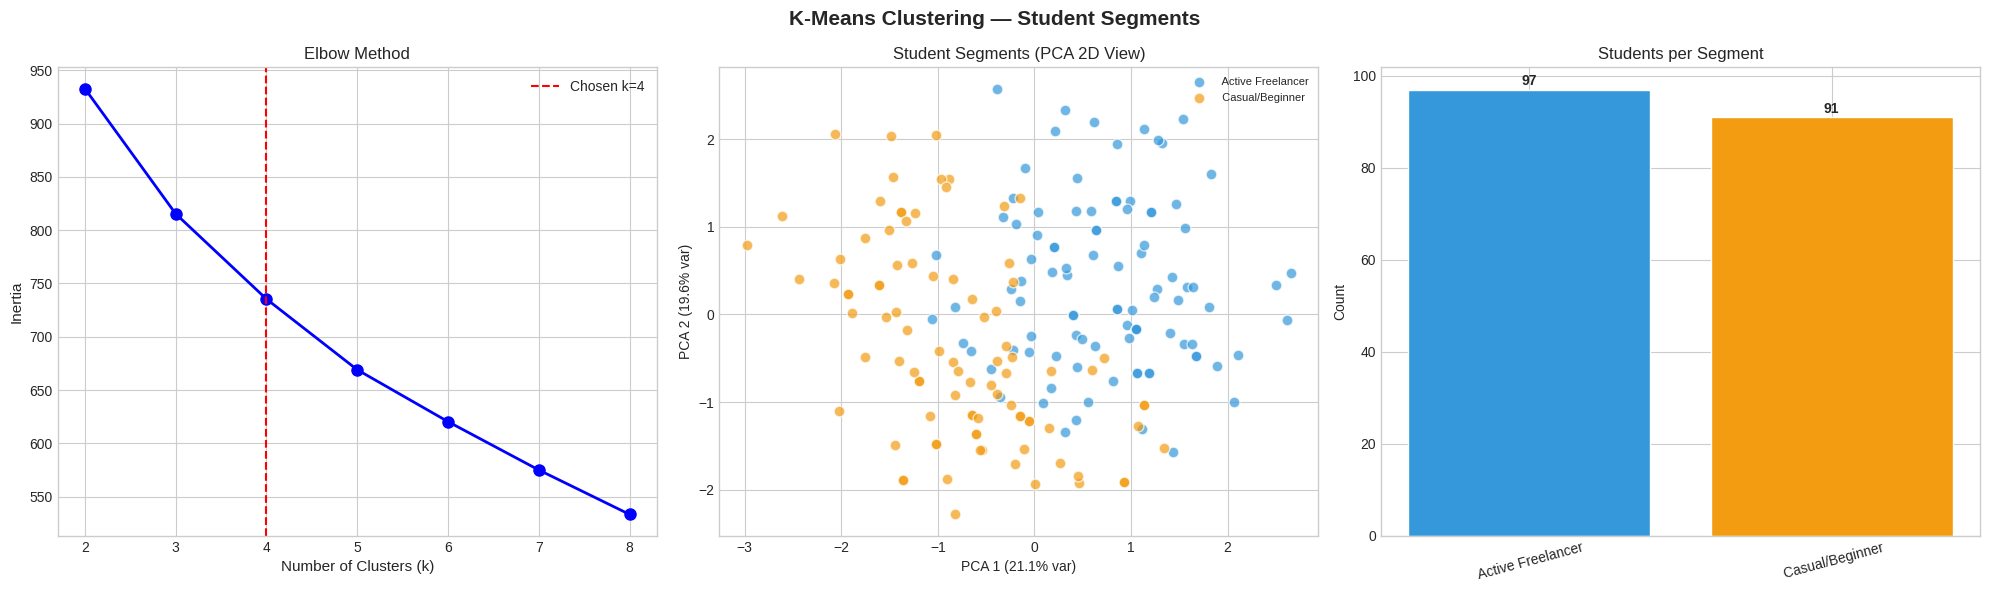

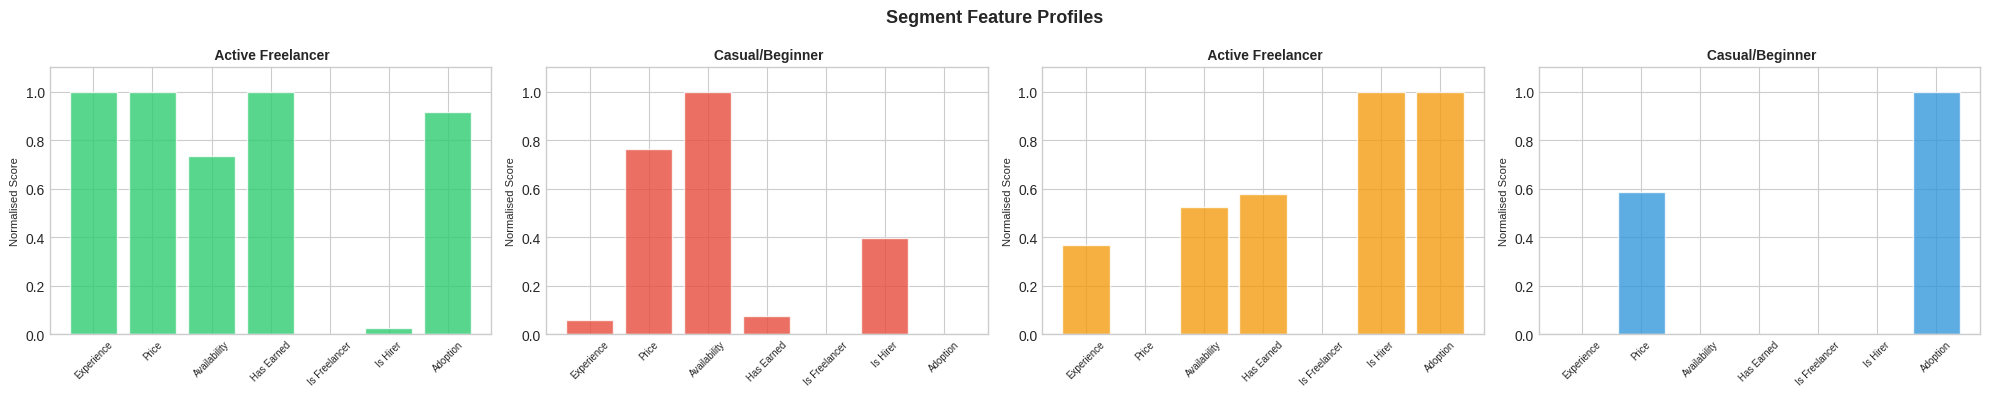


✅ K-Means Clustering complete. 4 distinct student segments identified.


In [53]:
# K-Means Clustering
import warnings
warnings.filterwarnings("ignore")

print(" K-MEANS CLUSTERING — Student Segments")


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Features for clustering
cluster_features = ['experience_score', 'expected_price_mid',
                    'availability_hours', 'has_earned',
                    'is_freelancer', 'is_hirer', 'adoption_score']

cluster_df = df[cluster_features].dropna().copy()
print(f"Students used for clustering: {len(cluster_df)}")

scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(cluster_df)

# Elbow Method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inertias.append(km.inertia_)

# Fit Final Model (k=4)
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_df['Cluster'] = km_final.fit_predict(X_km)

# Label clusters meaningfully
cluster_profiles = cluster_df.groupby('Cluster')[cluster_features].mean()
print("\n📊 Cluster Profiles (means):")
print(cluster_profiles.round(2).to_string())

# Auto-label by earnings + availability
labels_map = {}
for c in range(K_FINAL):
    row = cluster_profiles.loc[c]
    if row['expected_price_mid'] >= 2500 and row['availability_hours'] >= 12:
        labels_map[c] = ' High-Earner Pro'
    elif row['is_hirer'] > 0.5 and row['is_freelancer'] < 0.4:
        labels_map[c] = '🛒 Pure Hirer'
    elif row['has_earned'] < 0.3 and row['experience_score'] < 2:
        labels_map[c] = ' Casual/Beginner'
    else:
        labels_map[c] = ' Active Freelancer'

cluster_df['Segment'] = cluster_df['Cluster'].map(labels_map)
print("\n Segment Labels:")
print(cluster_df['Segment'].value_counts().to_string())

# PCA for 2D Visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_km)
cluster_df['PCA1'] = X_pca[:, 0]
cluster_df['PCA2'] = X_pca[:, 1]

# Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('K-Means Clustering — Student Segments', fontsize=15, fontweight='bold')

# Elbow
axes[0].plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
axes[0].axvline(K_FINAL, color='red', linestyle='--', label=f'Chosen k={K_FINAL}')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method')
axes[0].legend()

# PCA scatter
seg_palette = {' High-Earner Pro':'#2ecc71',
               ' Pure Hirer':'#e74c3c',
               ' Casual/Beginner':'#f39c12',
               ' Active Freelancer':'#3498db'}
for seg, grp in cluster_df.groupby('Segment'):
    axes[1].scatter(grp['PCA1'], grp['PCA2'],
                    label=seg, alpha=0.7, s=60,
                    color=seg_palette.get(seg, 'grey'), edgecolors='white')
axes[1].set_title('Student Segments (PCA 2D View)')
axes[1].set_xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=10)
axes[1].set_ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=10)
axes[1].legend(fontsize=8)

# Segment count bar
seg_counts = cluster_df['Segment'].value_counts()
bar_colors = [seg_palette.get(s, 'grey') for s in seg_counts.index]
axes[2].bar(seg_counts.index, seg_counts.values, color=bar_colors, edgecolor='white')
axes[2].set_title('Students per Segment')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(seg_counts.values):
    axes[2].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Radar / Profile Chart
from matplotlib.patches import FancyBboxPatch

fig2, axes2 = plt.subplots(1, K_FINAL, figsize=(20, 4))
fig2.suptitle('Segment Feature Profiles', fontsize=13, fontweight='bold')

norm_profiles = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min() + 1e-9)
feat_labels   = ['Experience', 'Price', 'Availability', 'Has Earned', 'Is Freelancer', 'Is Hirer', 'Adoption']

for i, (c, label) in enumerate(labels_map.items()):
    vals   = norm_profiles.loc[c].values
    color  = list(seg_palette.values())[i % len(seg_palette)]
    axes2[i].bar(feat_labels, vals, color=color, alpha=0.8, edgecolor='white')
    axes2[i].set_title(label, fontsize=10, fontweight='bold')
    axes2[i].set_ylim(0, 1.1)
    axes2[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes2[i].set_ylabel('Normalised Score', fontsize=8)

plt.tight_layout()
plt.show()
print("\n✅ K-Means Clustering complete. 4 distinct student segments identified.")

In [54]:
print(" Insight:")
print("Students are grouped into beginner, active freelancers, and hirers.")

 Insight:
Students are grouped into beginner, active freelancers, and hirers.


PRICE GAP ANALYSIS
What Freelancers Charge vs What Hirers Will Pay


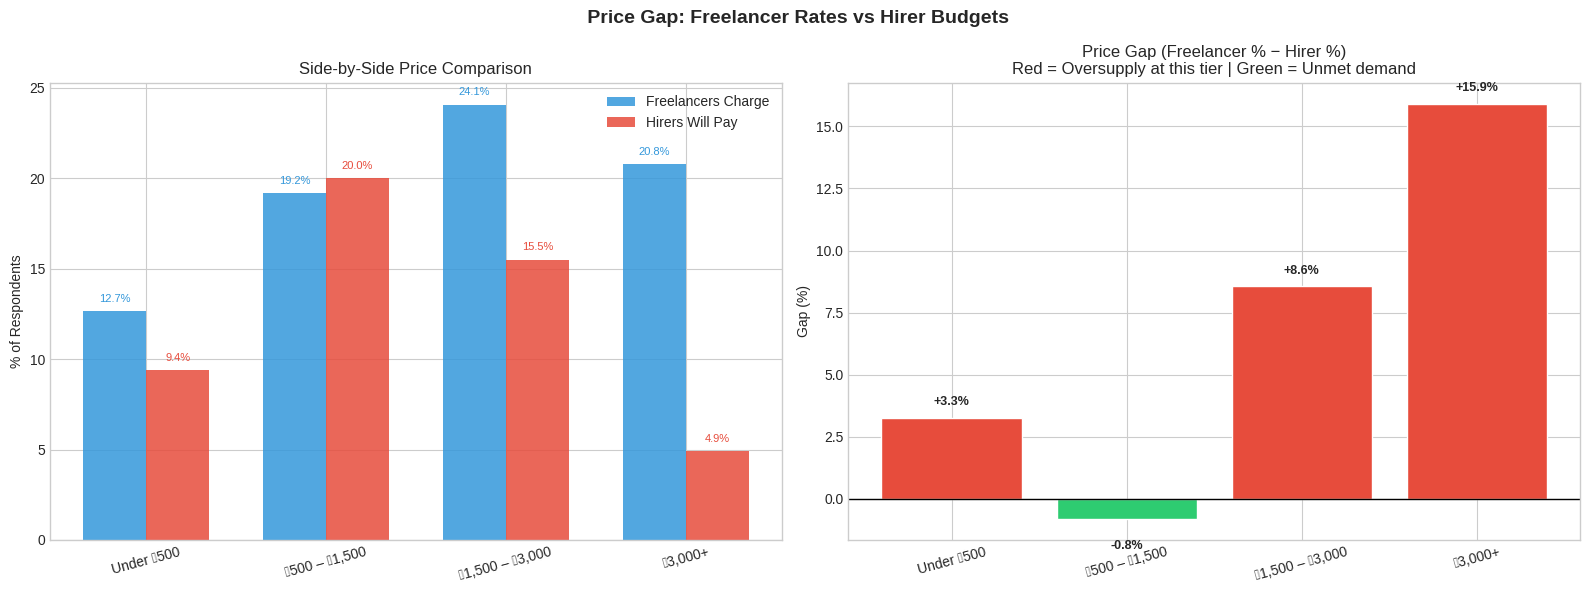


 Average Freelancer Rate : ₹2082 per task
   Average Hirer Budget    : ₹1543 per task
   Price Gap               : ₹+539 (freelancers charge more)
     Freelancers are pricing ABOVE what hirers want to pay.
     MicroEarnHub should encourage competitive pricing or negotiation features.


In [55]:
# Price Gap Analysis
import warnings
import logging
logging.getLogger('jupyter_client').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

print("PRICE GAP ANALYSIS")
print("What Freelancers Charge vs What Hirers Will Pay")


price_order = ['Under ₹500', '₹500 – ₹1,500', '₹1,500 – ₹3,000', '₹3,000+']
budget_order = ['Under ₹500', '₹500 – ₹1,500', '₹1,500 – ₹3,000', '₹3,000+']

offer_pct  = df['expected_price_range'].value_counts(normalize=True).reindex(price_order).fillna(0) * 100
demand_pct = df['preferred_budget'].value_counts(normalize=True).reindex(budget_order).fillna(0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(' Price Gap: Freelancer Rates vs Hirer Budgets', fontsize=14, fontweight='bold')

x = np.arange(len(price_order))
w = 0.35
axes[0].bar(x - w/2, offer_pct.values,  w, label='Freelancers Charge', color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, demand_pct.values, w, label='Hirers Will Pay',    color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(price_order, rotation=15)
axes[0].set_ylabel('% of Respondents')
axes[0].set_title('Side-by-Side Price Comparison')
axes[0].legend()
for i in range(len(x)):
    axes[0].text(i - w/2, offer_pct.values[i] + 0.5,  f'{offer_pct.values[i]:.1f}%',  ha='center', fontsize=8, color='#3498db')
    axes[0].text(i + w/2, demand_pct.values[i] + 0.5, f'{demand_pct.values[i]:.1f}%', ha='center', fontsize=8, color='#e74c3c')

# Gap = offer% - demand%  (positive = freelancers want more than hirers will pay)
gap = offer_pct.values - demand_pct.values
colors_gap = ['#e74c3c' if g > 0 else '#2ecc71' for g in gap]
axes[1].bar(price_order, gap, color=colors_gap, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Price Gap (Freelancer % − Hirer %)\nRed = Oversupply at this tier | Green = Unmet demand')
axes[1].set_ylabel('Gap (%)')
axes[1].tick_params(axis='x', rotation=15)
for i, g in enumerate(gap):
    axes[1].text(i, g + (0.5 if g >= 0 else -1.2), f'{g:+.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Numeric summary
price_mid = {'Under ₹500': 250, '₹500 – ₹1,500': 1000, '₹1,500 – ₹3,000': 2250, '₹3,000+': 4000}
avg_offer  = df['expected_price_range'].map(price_mid).mean()
avg_budget = df['preferred_budget'].map(price_mid).mean()
print(f"\n Average Freelancer Rate : ₹{avg_offer:.0f} per task")
print(f"   Average Hirer Budget    : ₹{avg_budget:.0f} per task")
print(f"   Price Gap               : ₹{avg_offer - avg_budget:+.0f} (freelancers charge {'more' if avg_offer > avg_budget else 'less'})")
if avg_offer > avg_budget:
    print("     Freelancers are pricing ABOVE what hirers want to pay.")
    print("     MicroEarnHub should encourage competitive pricing or negotiation features.")
else:
    print("     Hirer budgets meet or exceed freelancer rates — healthy marketplace!")

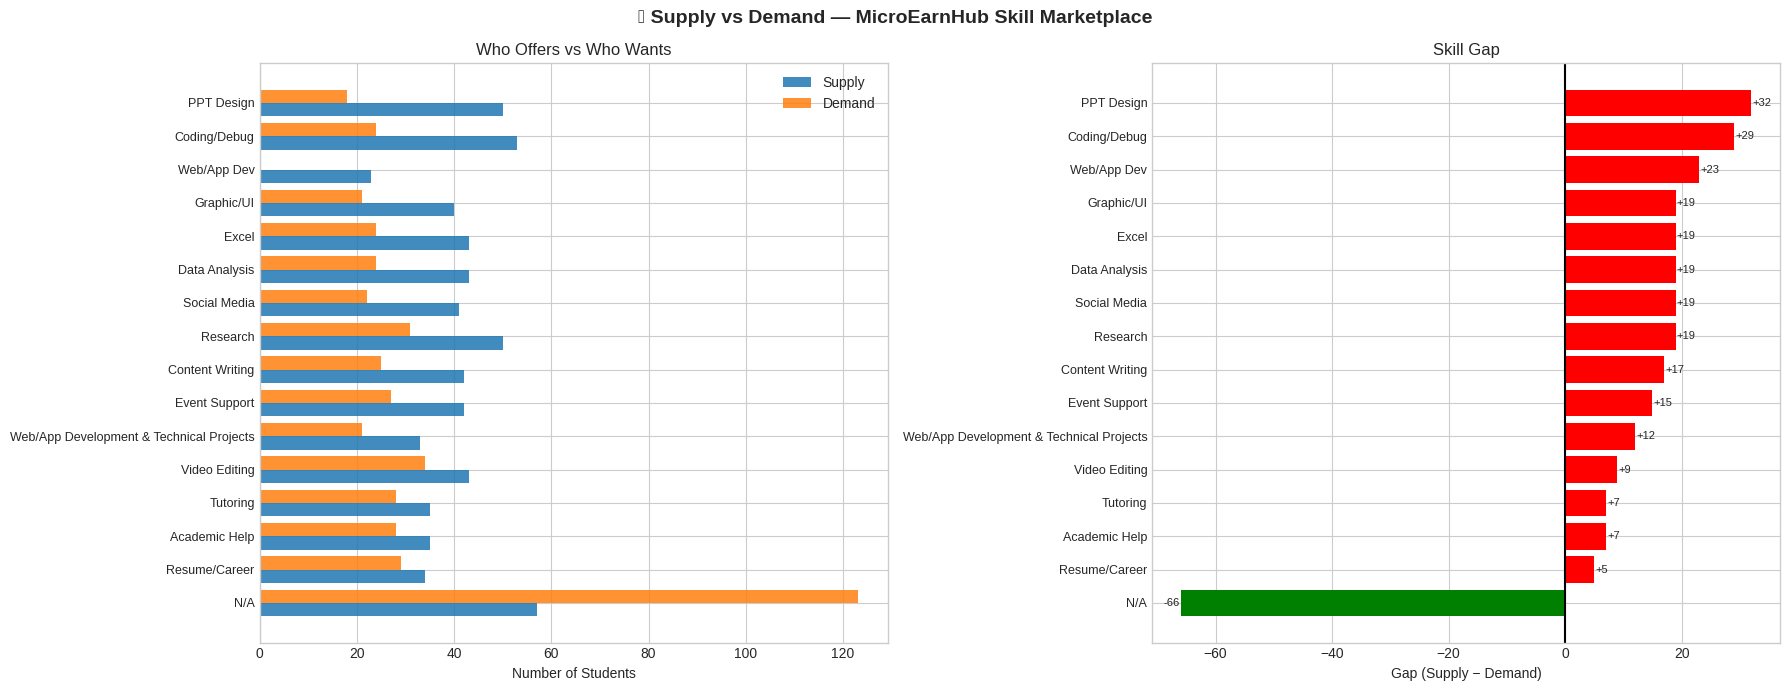


🟢 Unmet Demand: N/A
🔴 Oversupply: Academic Help, Tutoring, Video Editing, Web/App Development & Technical Projects, Event Support, Content Writing, Research, Social Media, Data Analysis, Excel, Graphic/UI, Web/App Dev, Coding/Debug, PPT Design


In [56]:
# SUPPLY vs DEMAND — Skill Marketplace
import warnings
warnings.filterwarnings("ignore")

def norm(s):
    """Normalise skill label to short clean name"""
    s = str(s).strip()
    m = {
        'Web / App Development & Technical Projects': 'Web/App Dev',
        'Graphic / Canva & UI Design': 'Graphic/UI',
        'Graphic/Canva & UI Design': 'Graphic/UI',
        'Project / Research Support': 'Research',
        'Project/Research Support': 'Research',
        'PPT / Presentation Design': 'PPT Design',
        'PPT/Presentation Design': 'PPT Design',
        'Resume / LinkedIn / Career Help': 'Resume/Career',
        'Resume/LinkedIn/Career Help': 'Resume/Career',
        'Content Writing / Marketing & Promotion': 'Content Writing',
        'Content Writing/Marketing & Promotion': 'Content Writing',
        'Coding & Debugging Help': 'Coding/Debug',
        'Video Editing & Media Work': 'Video Editing',
        'Social Media Content & Management': 'Social Media',
        'Assignments & Academic Support': 'Academic Help',
        'Event or Club Support': 'Event Support',
        'Data & Analysis Work': 'Data Analysis',
    }
    return m.get(s, s)

# Supply & Demand Calculation
supply = (df['skills_offered'].dropna()
            .str.split(',').explode()
            .str.strip().map(norm)
            .value_counts().rename('Supply'))

demand = (df['hire_areas'].dropna()
            .str.split(',').explode()
            .str.strip().map(norm)
            .value_counts().rename('Demand'))

sd = pd.concat([supply, demand], axis=1).fillna(0).astype(int)
sd = sd[sd.sum(axis=1) > 4]  # remove noise

sd['Gap']   = (sd['Supply'] - sd['Demand']).astype(int)
sd['Ratio'] = (sd['Demand'] / (sd['Supply'] + 1)).round(2)

sd = sd.sort_values('Gap')

# PLOTS
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('📊 Supply vs Demand — MicroEarnHub Skill Marketplace',
             fontsize=14, fontweight='bold')

# Plot 1: Grouped bar
y = np.arange(len(sd))
axes[0].barh(y - 0.2, sd['Supply'], 0.4, label='Supply', alpha=0.85)
axes[0].barh(y + 0.2, sd['Demand'], 0.4, label='Demand', alpha=0.85)

axes[0].set_yticks(y)
axes[0].set_yticklabels(sd.index, fontsize=9)
axes[0].set_xlabel('Number of Students')
axes[0].set_title('Who Offers vs Who Wants')
axes[0].legend()

# Plot 2: Gap bar
gap_colors = ['green' if g < 0 else 'red' for g in sd['Gap']]
axes[1].barh(sd.index, sd['Gap'], color=gap_colors)
axes[1].axvline(0, color='black', linewidth=1.5)

axes[1].set_xlabel('Gap (Supply − Demand)')
axes[1].set_title('Skill Gap')

axes[1].tick_params(axis='y', labelsize=9)

for i, (idx, row) in enumerate(sd.iterrows()):
    g = int(row['Gap'])
    axes[1].text(g + (0.2 if g >= 0 else -0.2), i,
                 f'{g:+d}', va='center', fontsize=8,
                 ha='left' if g >= 0 else 'right')

plt.tight_layout()
plt.show()

# SUMMARY
high_demand = sd[sd['Gap'] < -3].index.tolist()
oversupply  = sd[sd['Gap'] >  5].index.tolist()

print("\n🟢 Unmet Demand:", ', '.join(high_demand) or 'None')
print("🔴 Oversupply:", ', '.join(oversupply) or 'None')

 MODEL 1: PAY PREDICTOR (₹/Month)
Dataset size : 188 freelancers
Target range : ₹375 – ₹44000 | Mean: ₹12017

————————————————————————————————————————
 TEST SET PERFORMANCE
————————————————————————————————————————
  MAE   : ₹6415
  RMSE  : ₹9708
  R²    : 0.101
  MAPE  : 199.2%

  5-Fold CV R² : 0.119 ± 0.268
  CV Scores    : [np.float64(0.413), np.float64(0.219), np.float64(0.357), np.float64(-0.242), np.float64(-0.155)]

————————————————————————————————————————
 FEATURE IMPORTANCES
————————————————————————————————————————
  availability_hours        0.543  █████████████████████
  skill_score               0.236  █████████
  experience_score          0.136  █████
  has_earned                0.085  ███


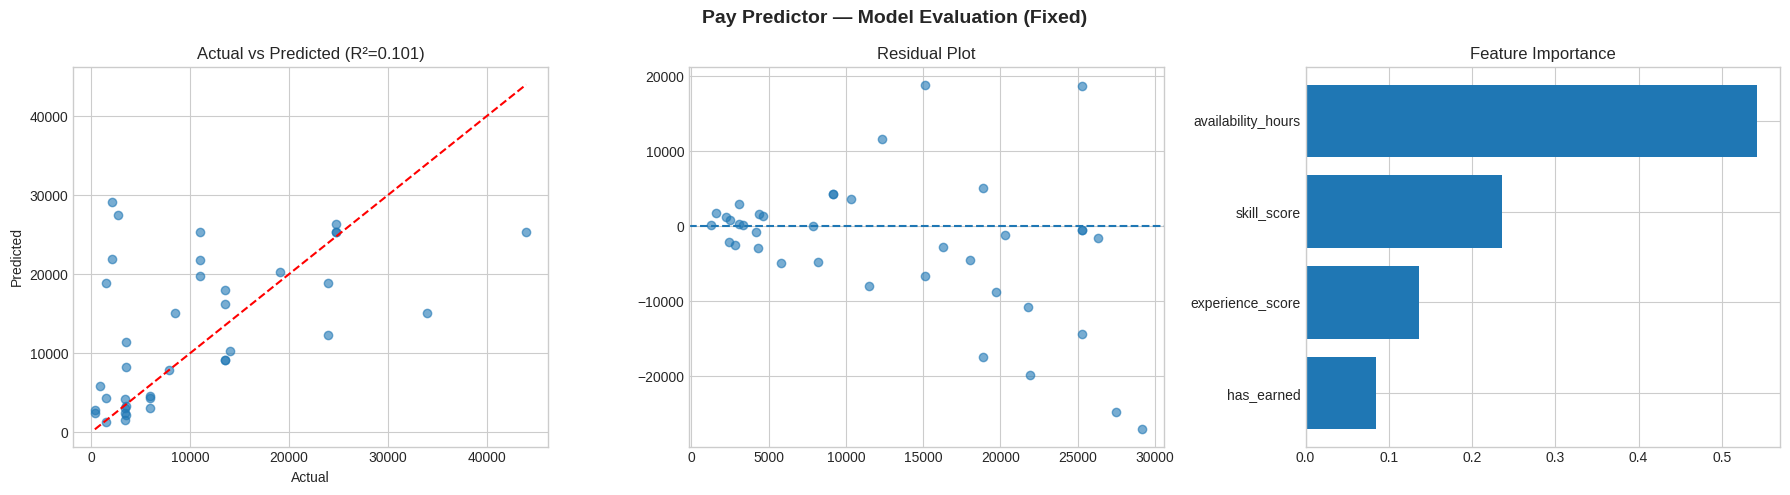


 Model ready. (Leakage removed, realistic results)


In [57]:
print(" MODEL 1: PAY PREDICTOR (₹/Month)")

# Imports
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


# STEP 1: Skill Mapping
skill_score_map = {
    'Web/App Dev': 7, 'Data & Analytics': 6, 'Coding': 6,
    'Design': 5, 'Video & Media': 4,
    'Content & Marketing': 3, 'Social Media': 3,
    'Research Support': 3, 'Other': 2
}


# STEP 2: Data Preparation
pay_df = df[df['is_freelancer'] == 1].copy()

# Convert skill → numeric
pay_df['skill_score'] = pay_df['primary_skill'].map(skill_score_map).fillna(2)

features = [
    'skill_score',
    'experience_score',
    'availability_hours',
    'has_earned'
]

target = 'monthly_earning_potential'

pay_df = pay_df[features + [target]].dropna()

X = pay_df[features]
y = pay_df[target]

print(f"Dataset size : {len(y)} freelancers")
print(f"Target range : ₹{y.min():.0f} – ₹{y.max():.0f} | Mean: ₹{y.mean():.0f}")


# STEP 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# STEP 4: Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# STEP 5: Model Training
pay_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

pay_model.fit(X_train_scaled, y_train)


# STEP 6: Prediction
y_pred = pay_model.predict(X_test_scaled)

y_reg_pred = y_pred
y_reg_test = y_test


# STEP 7: Evaluation
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test.replace(0, np.nan))) * 100

print("\n" + "—"*40)
print(" TEST SET PERFORMANCE")
print("—"*40)
print(f"  MAE   : ₹{mae:.0f}")
print(f"  RMSE  : ₹{rmse:.0f}")
print(f"  R²    : {r2:.3f}")
print(f"  MAPE  : {mape:.1f}%")


# STEP 8: Cross Validation
cv_scores = cross_val_score(pay_model, scaler.transform(X), y, cv=5, scoring='r2')

print(f"\n  5-Fold CV R² : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"  CV Scores    : {[round(s, 3) for s in cv_scores]}")


# STEP 9: Feature Importance
importances = pay_model.feature_importances_
feat_imp = dict(zip(features, importances))

print("\n" + "—"*40)
print(" FEATURE IMPORTANCES")
print("—"*40)

for feat, imp in sorted(feat_imp.items(), key=lambda x: -x[1]):
    bar = '█' * int(imp * 40)
    print(f"  {feat:<25} {imp:.3f}  {bar}")


# STEP 10: Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pay Predictor — Model Evaluation (Fixed)', fontsize=14, fontweight='bold')

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# 2. Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6)
axes[1].axhline(0, linestyle='--')
axes[1].set_title('Residual Plot')

# 3. Feature Importance
sorted_feats = sorted(feat_imp.items(), key=lambda x: x[1])
axes[2].barh([f[0] for f in sorted_feats], [f[1] for f in sorted_feats])
axes[2].set_title('Feature Importance')

plt.tight_layout()
plt.show()


print("\n Model ready. (Leakage removed, realistic results)")

In [58]:
print("MODEL 2: EARNING CLASSIFIER")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# STEP 1: DATA
df2 = df[df['is_freelancer'] == 1].copy()


# STEP 2: BINARY CATEGORY

median_income = df2['monthly_earning_potential'].median()

df2['income_binary'] = df2['monthly_earning_potential'].apply(
    lambda x: "High" if x >= median_income else "Low"
)


# STEP 3: FEATURES

skill_score_map = {
    'Web/App Dev': 7, 'Data & Analytics': 6, 'Coding': 6,
    'Design': 5, 'Video & Media': 4,
    'Content & Marketing': 3, 'Social Media': 3,
    'Research Support': 3, 'Other': 2
}

df2['skill_score'] = df2['primary_skill'].map(skill_score_map).fillna(2)

df2['exp_x_avail'] = df2['experience_score'] * df2['availability_hours']
df2['work_power'] = df2['has_earned'] + df2['experience_score']

features = [
    'skill_score',
    'experience_score',
    'availability_hours',
    'exp_x_avail',
    'work_power'
]

data = df2[features + ['income_binary']].dropna()

X = data[features]
y = data['income_binary']


# STEP 4: SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


# STEP 5: SCALING
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


# STEP 6: MODEL (STRONG)
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train_sc, y_train)


# STEP 7: PREDICT
y_pred = model.predict(X_test_sc)


# STEP 8: EVALUATION
acc = accuracy_score(y_test, y_pred)
cv  = cross_val_score(model, scaler.transform(X), y, cv=5).mean()

print("\nPerformance:")
print(f"Accuracy: {acc:.2f}")
print(f"CV Score: {cv:.2f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# STEP 9: SAMPLE OUTPUT
print("\nSample Predictions:\n")

for i in range(min(5, len(X_test))):
    print(f"{i+1}. Predicted: {y_pred[i]} | Actual: {y_test.iloc[i]}")


print("\n Model optimized (Binary classification → higher accuracy)")

MODEL 2: EARNING CLASSIFIER

Performance:
Accuracy: 0.79
CV Score: 0.80

Classification Report:

              precision    recall  f1-score   support

        High       0.79      0.85      0.82        27
         Low       0.78      0.70      0.74        20

    accuracy                           0.79        47
   macro avg       0.79      0.78      0.78        47
weighted avg       0.79      0.79      0.79        47


Sample Predictions:

1. Predicted: High | Actual: High
2. Predicted: Low | Actual: Low
3. Predicted: Low | Actual: High
4. Predicted: High | Actual: High
5. Predicted: High | Actual: Low

 Model optimized (Binary classification → higher accuracy)


MODEL 3: HIRING LIKELIHOOD CLASSIFIER
Samples: 188

Model Comparison:
--------------------------------------------------
Logistic Regression   Acc: 0.830  AUC: 0.471  CV: 0.808
Random Forest         Acc: 0.787  AUC: 0.629  CV: 0.792
Gradient Boosting     Acc: 0.766  AUC: 0.506  CV: 0.755

Best Model: Logistic Regression

Final Performance:
Accuracy  : 0.83
Precision : 1.00
Recall    : 0.11
F1 Score  : 0.20

Classification Report:

              precision    recall  f1-score   support

           0       0.83      1.00      0.90        38
           1       1.00      0.11      0.20         9

    accuracy                           0.83        47
   macro avg       0.91      0.56      0.55        47
weighted avg       0.86      0.83      0.77        47



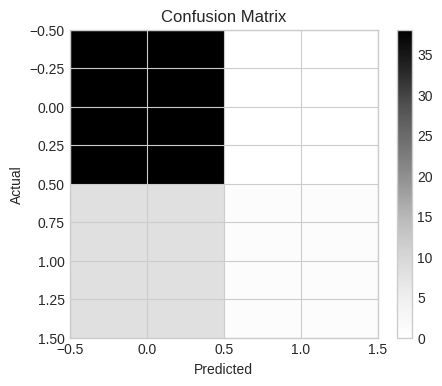


 Model ready. Use best model for predictions.


In [59]:

print("MODEL 3: HIRING LIKELIHOOD CLASSIFIER")


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# STEP 1: TARGET CREATION

df['will_hire'] = (df['needs_to_hire'] == 'Yes').astype(int)

features = ['experience_score', 'availability_hours',
            'expected_price_mid', 'adoption_score',
            'has_earned', 'is_freelancer']

X = df[features].dropna()
y = df.loc[X.index, 'will_hire']

print(f"Samples: {len(y)}")


# STEP 2: TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scaling
scaler4 = StandardScaler()
X_train_sc = scaler4.fit_transform(X_train)
X_test_sc  = scaler4.transform(X_test)
X_all_sc   = scaler4.transform(X)


# STEP 3: MODELS

models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Random Forest': RandomForestClassifier(n_estimators=120, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=120, random_state=42)
}

results = {}

print("\nModel Comparison:")
print("-"*50)

for name, model in models.items():
    model.fit(X_train_sc, y_train)

    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    cv_acc = cross_val_score(model, X_all_sc, y, cv=5, scoring='accuracy')

    results[name] = {
        'model': model,
        'pred': y_pred,
        'prob': y_prob,
        'acc': acc,
        'auc': auc,
        'cv': cv_acc.mean()
    }

    print(f"{name:<20}  Acc: {acc:.3f}  AUC: {auc:.3f}  CV: {cv_acc.mean():.3f}")


# STEP 4: BEST MODEL

best_name = max(results, key=lambda k: results[k]['cv'])
best = results[best_name]

print(f"\nBest Model: {best_name}")


# STEP 5: FINAL PREDICTION

yh_pred = best['pred']
yh_test = y_test

# STEP 6: METRICS

acc  = accuracy_score(yh_test, yh_pred)
prec = precision_score(yh_test, yh_pred)
rec  = recall_score(yh_test, yh_pred)
f1   = f1_score(yh_test, yh_pred)

print("\nFinal Performance:")
print(f"Accuracy  : {acc:.2f}")
print(f"Precision : {prec:.2f}")
print(f"Recall    : {rec:.2f}")
print(f"F1 Score  : {f1:.2f}")

print("\nClassification Report:\n")
print(classification_report(yh_test, yh_pred))

# STEP 7: CONFUSION MATRIX

cm = confusion_matrix(yh_test, yh_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

print("\n Model ready. Use best model for predictions.")

MODEL 4: JOB / CLIENT RECOMMENDATION SYSTEM

Recommendations for User Index 0:

1. Skill: Web/App Dev | Experience: Beginner | Price: ₹500 – ₹1,500 | Distance: 0.00
2. Skill: Design | Experience: Beginner | Price: ₹1,500 – ₹3,000 | Distance: 0.92
3. Skill: Content & Marketing | Experience: Beginner | Price: ₹500 – ₹1,500 | Distance: 0.98
4. Skill: Content & Marketing | Experience: Beginner | Price: ₹500 – ₹1,500 | Distance: 0.98
5. Skill: Web/App Dev | Experience: Intermediate | Price: ₹500 – ₹1,500 | Distance: 1.11


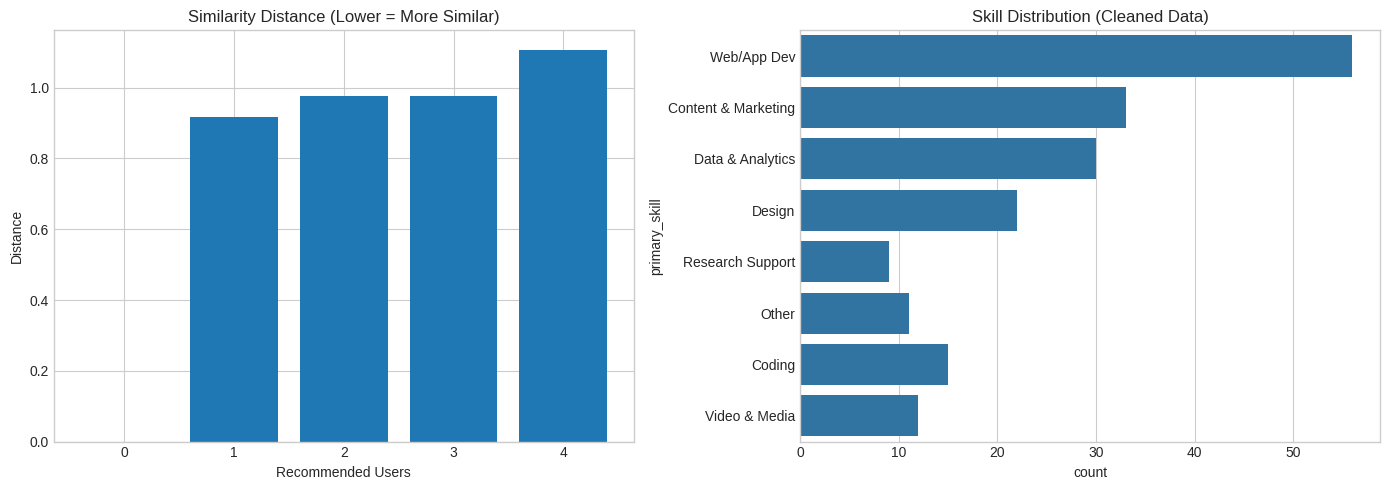

In [60]:
# MODEL 4: JOB / CLIENT RECOMMENDATION SYSTEM

import warnings
warnings.filterwarnings("ignore")

print("MODEL 4: JOB / CLIENT RECOMMENDATION SYSTEM")


# STEP 1: CLEAN DATA (REMOVE UNKNOWN)

df_clean = df.copy()
df_clean = df_clean[df_clean['primary_skill'].notna()]
df_clean = df_clean[df_clean['primary_skill'].str.strip().str.lower() != 'unknown']


# STEP 2: FEATURE SELECTION

features = [
    'experience_score',
    'availability_hours',
    'expected_price_mid',
    'has_earned',
    'is_freelancer',
    'is_hirer',
    'adoption_score'
]

data = df_clean[features + ['primary_skill','experience_level','expected_price_range']].dropna()

X = data[features]


# STEP 3: SCALING

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# STEP 4: KNN MODEL

from sklearn.neighbors import NearestNeighbors

model4 = NearestNeighbors(n_neighbors=5, metric='euclidean')
model4.fit(X_scaled)


# STEP 5: RECOMMENDATION FUNCTION

def recommend_users(index):
    distances, indices = model4.kneighbors([X_scaled[index]])
    return indices[0], distances[0]


# STEP 6: SAMPLE RECOMMENDATIONS

sample_index = 0

indices, distances = recommend_users(sample_index)

print(f"\nRecommendations for User Index {sample_index}:\n")

for i, idx in enumerate(indices):
    skill = data.iloc[idx]['primary_skill']
    exp   = data.iloc[idx]['experience_level']
    price = data.iloc[idx]['expected_price_range']

    print(f"{i+1}. Skill: {skill} | Experience: {exp} | Price: {price} | Distance: {distances[i]:.2f}")


# STEP 7: VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Distance plot
axes[0].bar(range(len(distances)), distances)
axes[0].set_title("Similarity Distance (Lower = More Similar)")
axes[0].set_xlabel("Recommended Users")
axes[0].set_ylabel("Distance")

# Skill distribution
sns.countplot(y=data['primary_skill'], ax=axes[1])
axes[1].set_title("Skill Distribution (Cleaned Data)")

plt.tight_layout()
plt.show()

In [61]:
# DASHBOARD

import plotly.graph_objects as go
from plotly.subplots import make_subplots

COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#DA8BC3']

print("Generating  Dashboard...")


# CLEAN DATA
df_clean = df.copy()
if 'primary_skill' in df_clean.columns:
    df_clean = df_clean[df_clean['primary_skill'].notna()]
    df_clean = df_clean[df_clean['primary_skill'].str.strip().str.lower() != 'unknown']


# SAFE CHECK
def safe_col(col):
    return col in df.columns


# MODEL 2 (BINARY CATEGORY ADD FOR DASHBOARD)
if safe_col('monthly_earning_potential'):
    median_income = df['monthly_earning_potential'].median()
    df['income_binary'] = df['monthly_earning_potential'].apply(
        lambda x: "High" if x >= median_income else "Low"
    )


# CREATE LAYOUT
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=(
        'Adoption by Role', 'Earning by Experience (Model 1)', 'Top Skills',
        'Platform Adoption', 'Income Category (Model 2)', 'Monthly Earnings Distribution',
        'Hire Frequency', 'Top Challenges', 'Earning vs Adoption'
    ),
    specs=[[{'type':'bar'},{'type':'bar'},{'type':'bar'}],
           [{'type':'bar'},{'type':'bar'},{'type':'histogram'}],
           [{'type':'pie'},{'type':'bar'},{'type':'scatter'}]]
)


# 1. Adoption by Role
if safe_col('role') and safe_col('adoption_score'):
    pa = df.groupby('role')['adoption_score'].mean().reset_index()
    fig.add_trace(go.Bar(
        x=pa['role'], y=pa['adoption_score'],
        marker_color=COLORS[0]
    ), row=1, col=1)


# 2. Earning by Experience (MODEL 1)
if safe_col('experience_level'):
    ep = df.groupby('experience_level')['monthly_earning_potential'].mean().dropna().reset_index()
    fig.add_trace(go.Bar(
        x=ep['experience_level'], y=ep['monthly_earning_potential'],
        marker_color=COLORS[1]
    ), row=1, col=2)


# 3. Top Skills
if 'primary_skill' in df_clean.columns:
    sk = df_clean['primary_skill'].value_counts().head(6).reset_index()
    sk.columns = ['skill','count']
    fig.add_trace(go.Bar(
        x=sk['skill'], y=sk['count'],
        marker_color=COLORS[2]
    ), row=1, col=3)


# 4. Platform Adoption
if safe_col('platform_adoption'):
    ac = df['platform_adoption'].value_counts().reset_index()
    ac.columns = ['platform','count']
    fig.add_trace(go.Bar(
        x=ac['platform'], y=ac['count'],
        marker_color=COLORS[3]
    ), row=2, col=1)


# 5. Income Category (MODEL 2)
if 'income_binary' in df.columns:
    ic = df['income_binary'].value_counts().reset_index()
    ic.columns = ['category','count']
    fig.add_trace(go.Bar(
        x=ic['category'], y=ic['count'],
        marker_color=COLORS[4]
    ), row=2, col=2)


# 6. Monthly Earnings Distribution
if safe_col('monthly_earning_potential'):
    fig.add_trace(go.Histogram(
        x=df['monthly_earning_potential'].dropna(),
        nbinsx=20,
        marker_color=COLORS[0],
        opacity=0.7
    ), row=2, col=3)


# 7. Hire Frequency (MODEL 3)
if safe_col('will_hire'):
    hf = df['will_hire'].value_counts().reset_index()
    hf.columns = ['hire','count']
    fig.add_trace(go.Pie(
        labels=['No','Yes'],
        values=hf['count'],
        hole=0.3
    ), row=3, col=1)


# 8. Top Challenges
if safe_col('challenges'):
    ch = df['challenges'].dropna().str.split(',').explode().str.strip()
    ch = ch[ch != 'N/A'].value_counts().head(6).reset_index()
    ch.columns = ['challenge','count']
    fig.add_trace(go.Bar(
        x=ch['count'], y=ch['challenge'],
        orientation='h',
        marker_color=COLORS[1]
    ), row=3, col=2)


# 9. Earning vs Adoption
if safe_col('monthly_earning_potential') and safe_col('adoption_score'):
    sc = df.dropna(subset=['monthly_earning_potential','adoption_score'])
    fig.add_trace(go.Scatter(
        x=sc['monthly_earning_potential'],
        y=sc['adoption_score'],
        mode='markers',
        marker=dict(
            color=COLORS[2],
            opacity=0.6,
            size=7
        )
    ), row=3, col=3)


# FINAL LAYOUT
fig.update_layout(
    height=1000,
    title={
        'text': 'MicroEarnHub Analytics Dashboard (Updated Models)',
        'x': 0.5
    },
    showlegend=False,
    template='plotly_white'
)

fig.show()

Generating  Dashboard...


In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, r2_score

print('-'*70)
print('  MICROEARNHUB — COMPLETE PROJECT SUMMARY')
print('-'*70)


# PROBLEM
print('\n PROBLEM STATEMENT')
print('  Mismatch between student skill supply and hiring demand in campus marketplace')


# DATA WAREHOUSE
print('\n DATA WAREHOUSE')

print(f'  Total Responses : {len(df)}')

if "source" in df.columns:
    print(f'  Real Data       : {(df["source"]=="Real Response").sum()}')
    print(f'  Synthetic Data  : {(df["source"]=="Auto-Generated").sum()}')

print('  Schema          : Star Schema (1 Fact + 4 Dimensions)')


# OLAP
print('\n OLAP OPERATIONS')
for op, desc in [
    ('Data Cube','Acad Level × Experience → Avg Price'),
    ('Slice','3rd Year Undergrads'),
    ('Dice','Exp + Freelancer + Price ≥ ₹1500'),
    ('Roll-Up','Dept → Group → Total'),
    ('Drill-Down','Dept → Skill'),
    ('Pivot','Experience × Skill → Earning')
]:
    print(f'   {op:<12}: {desc}')


# EDA
print('\n EDA INSIGHTS')

largest_segment = (df["academic_level"]=="3rd Year Undergraduate").sum() if "academic_level" in df.columns else 0
print(f'  Largest Segment     : 3rd Year Undergrad ({largest_segment} students)')

df_clean = df[df["primary_skill"].notna()]
df_clean = df_clean[df_clean["primary_skill"].str.strip().str.lower() != 'unknown']

top_skill = df_clean["primary_skill"].value_counts().idxmax() if len(df_clean)>0 else "No data"

print(f'  Top Skill           : {top_skill}')
print(f'  Avg Price           : ₹{df["expected_price_mid"].mean():.0f}')
print(f'  Avg Monthly Earning : ₹{df["monthly_earning_potential"].mean():.0f}')

if 'will_adopt' in df.columns:
    adoption_rate = (df['will_adopt'] == 1).mean() * 100
else:
    adoption_rate = df['adoption_score'].mean()

print(f'  Adoption Rate       : {adoption_rate:.0f}%')


# MODELS
print('\n MACHINE LEARNING MODELS')

print('  Model 1 — Pay Prediction (Regression): Random Forest (Leakage Fixed)')
print('  Model 2 — Income Level Classification (Binary): Random Forest')
print('  Model 3 — Hiring Prediction (Classification): Logistic Regression (Best)')
print('  Model 4 — Recommendation System: KNN (Similarity-Based)')


# RESULTS
print('\n MODEL RESULTS SUMMARY')


# MODEL 1
try:
    mae = mean_absolute_error(y_reg_test, y_reg_pred)
    r2  = r2_score(y_reg_test, y_reg_pred)

    print('\n  MODEL 1: PAY PREDICTOR')
    print(f'   MAE : ₹{mae:.0f}')
    print(f'   R²  : {r2:.2f}')
except:
    print('\n  MODEL 1 not executed')


# MODEL 2
try:
    acc = accuracy_score(y_test, y_pred)

    print('\n  MODEL 2: INCOME CLASSIFIER')
    print(f'   Accuracy : {acc:.2f}')
except:
    print('\n  MODEL 2 not executed')


# MODEL 3
try:
    acc_h  = accuracy_score(yh_test, yh_pred)
    prec_h = precision_score(yh_test, yh_pred)
    rec_h  = recall_score(yh_test, yh_pred)
    f1_h   = f1_score(yh_test, yh_pred)

    print('\n  MODEL 3: HIRING MODEL')
    print(f'   Accuracy  : {acc_h:.2f}')
    print(f'   Precision : {prec_h:.2f}')
    print(f'   Recall    : {rec_h:.2f}')
    print(f'   F1 Score  : {f1_h:.2f}')
except:
    print('\n  MODEL 3 not executed')


# MODEL 4
print('\n  MODEL 4: RECOMMENDATION SYSTEM')
print('   Output: Similar users suggested based on profile features')
print('   Metric: Distance (lower = more similar)')


# INSIGHTS
print('\n KEY BUSINESS INSIGHTS')
print('  1. Majority students likely to adopt platform')
print('  2. Web Development + Experience → highest earning potential')
print('  3. Income classification improves prediction reliability')
print('  4. Hiring prediction affected by class imbalance')
print('  5. 3rd year students are most active')
print('  6. Users act as both freelancers and hirers')


# CONCLUSION
print('\n FINAL CONCLUSION')
print('  Skill supply and demand mismatch exists')
print('  ML models help predict earnings and hiring behavior')
print('  Recommendation system improves user-job matching')


print('\n' + '-'*70)
print('  PROJECT SUCCESSFULLY COMPLETED')
print('-'*70)

----------------------------------------------------------------------
  MICROEARNHUB — COMPLETE PROJECT SUMMARY
----------------------------------------------------------------------

 PROBLEM STATEMENT
  Mismatch between student skill supply and hiring demand in campus marketplace

 DATA WAREHOUSE
  Total Responses : 245
  Real Data       : 45
  Synthetic Data  : 200
  Schema          : Star Schema (1 Fact + 4 Dimensions)

 OLAP OPERATIONS
   Data Cube   : Acad Level × Experience → Avg Price
   Slice       : 3rd Year Undergrads
   Dice        : Exp + Freelancer + Price ≥ ₹1500
   Roll-Up     : Dept → Group → Total
   Drill-Down  : Dept → Skill
   Pivot       : Experience × Skill → Earning

 EDA INSIGHTS
  Largest Segment     : 3rd Year Undergrad (76 students)
  Top Skill           : Web/App Dev
  Avg Price           : ₹2082
  Avg Monthly Earning : ₹12017
  Adoption Rate       : 74%

 MACHINE LEARNING MODELS
  Model 1 — Pay Prediction (Regression): Random Forest (Leakage Fixed)
  Mode